In [1]:
### Import relevant Python modules
import pandas as pd
import numpy as np
import matplotlib
#matplotlib.use("Agg")##this is to prevent python rocketship jumping in the command pannel of MAC
matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import matplotlib.patches as patch
import scipy.interpolate
%matplotlib inline
import os
import math
import seaborn as snsv
import random

### Modules working with images
import skimage
from skimage import data
from skimage import io
from skimage import morphology
footprint = morphology.disk(3)
import os
from skimage import filters
import math
from pystackreg import StackReg

import ast
import copy

In [2]:
### Colour maps for punctum visualisation (overlay with the microscopy image) 
# (NaN values will be transparent)
red_ = copy.copy(plt.cm.get_cmap('bwr_r')) # copy of the original cmap
red_.set_bad(alpha=0) # 'bad' values will be transparent

green_ = copy.copy(plt.cm.get_cmap('brg_r'))
green_.set_bad(alpha = 0)

blue_ = copy.copy(plt.cm.get_cmap('bwr')) # copy of the original cmap
blue_.set_bad(alpha=0) # 'bad' values will be transparent


In [3]:
## Grid/array to make the mask

nrows = 1024 # rows of px in the image
ncols = 1024 # number of columns in the image
row, col = np.ogrid[:nrows, :ncols]

In [4]:
### Function to extract parameters of the ellipse from the BudJ table
# use it to make the mask 

def ellipse(BudJ_table, scaling_factor):
    h = float(BudJ_table['x'])/scaling_factor
    k = float(BudJ_table['y'])/scaling_factor
    a = float(BudJ_table["major R"])/scaling_factor
    b = float(BudJ_table["minor r"])/scaling_factor
    A = float(BudJ_table['angle'])*(math.pi/180)
    return h, k, a, b, A

scaling_factor = 1/15.4943 # micron/px

#### Function to create a manually curated/visually validated data set
**NB. Inbuilt visualisation:** function also returns the masks that show the brightest (clear) and miscellaneous puncta when overlayed with the microscopy image.

In [5]:
def PF_validated_data(fluor_image, cell_mask, punctum_diameter, overlap, N_clear, N_misc, N_doubt):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    df_output = pd.DataFrame({}) # empty dataframe that will contain output data
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):       
        return False, False, False, False, print("cell too close to FOV edge")
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            return False, False, False, False, print("cell too close to FOV edge")
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: assess all punctum candidates
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner

            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter+4, punctum_diameter+4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)

                    if ratio_fluor_local > 1 and ratio_fluor_overall > 1: 
                        ## save information pertaining to this location
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["diameter"] = punctum_diameter
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]

                        # dataframe with all candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### PART 2b: remove candidate puncta that are too close together/overlap too much    
            ## Goal: remove locations that overlap more than you allow; keep the brightest candidate punctum 
            
            # first, sort the data frame from brightest to dimmest candidate (sort by fluorescence intensity ratio punctum/cell)
            df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
            
            # clean up the indices on the data frame with all potential puncta
            df_puncta = df_puncta.reset_index()
            df_puncta = df_puncta.drop("index", axis = 1)
    
            # compare each potential punctum against all puncta above it in the data frame
            initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
            for i1 in initial_label:
                current_row = df_puncta.loc[i1]
                label_list = list(df_puncta.index) # all id's currently present in the table
                current_index = label_list.index(i1) # index of current row's id, to know how many candidates to compare against (candidates that are above it in the table)
                for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                    prev_label = label_list[i2]
                    prev_row = df_puncta.loc[prev_label]
                    # extract relevant information about the 2 candidate puncta
                    current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                    current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                    max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                    current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                    # check for overlap between candidate puncta
                    if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                        continue # start next iteration of the loop
                        
                    elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                        continue # start next iteration of the loop
                        
                    else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                        # selection of the characteristic that will be combined to decide which candidate is best
                        current = current_overall; prev = prev_overall
                        # actual comparison between candidates (+ removal of the worst one)
                        if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                            df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                            break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                        else: # the other candidate is the one that should be removed
                            df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
            
            # now sort by LOCAL fluorescence intensity ratio
            df_puncta = df_puncta.sort_values(by = ["intensity ratio, local"], ascending = False)
            
            ## clean up indices of df_puncta, so that index values will match those recorded for clear and miscellaneous puncta
            df_puncta = df_puncta.reset_index()
            df_puncta = df_puncta.drop("index", axis=1)
            
            #### PART 3: assign an identity to each remaining location (punctate, miscellaneous, nonpunctate)
            ## approach: sort all locations (which don't overlap too much) based on local or overall fluorescence ratio
            ## the N_clear best locations are labeled punctate, the next N_misc locations are labeled miscellaneous, all others are nonpunctate
            ## N_clear and N_misc are based on visual inspection
            
            # split df_puncta into three parts: one for punctate locations, one for miscellaneous, one for nonpunctate
            df_punctate = df_puncta.iloc[:N_clear]
            df_misc = df_puncta.iloc[N_clear:N_clear + N_misc]
            df_doubt = df_puncta.iloc[N_clear + N_misc: N_clear + N_misc + N_doubt]
            df_nonpunctate = df_puncta.iloc[N_clear + N_misc + N_doubt:]
            
            # to each df, add a column describing the state of each candidate punctum
            df_nonpunctate["state"] = len(df_nonpunctate)*["nonpunctate"]
            df_doubt["state"] = len(df_doubt)*["miscellaneous"]
            df_misc["state"] = len(df_misc)*["punctum (clear)"]
            df_punctate["state"] = len(df_punctate)*["punctum (brightest)"]
            df_output = pd.concat([df_output, df_punctate, df_misc, df_doubt, df_nonpunctate])
            
            #### PART 4: create masks that show N_clear best clear puncta and the N_misc next best miscellaneous puncta  (number of puncta in each category as determined by visual inspection)
                
            height = len(masked); width = len(masked[0])
            mask_puncta_clear = np.empty((height, width, )); mask_puncta_clear[:] = np.nan 
            mask_puncta_misc = np.empty((height, width, )); mask_puncta_misc[:] = np.nan
            mask_puncta_doubt = np.empty((height, width, )); mask_puncta_doubt[:] = np.nan
            
            ## first create the mask for the clear puncta
            x_coordinates = list(df_punctate["x"]); y_coordinates = list(df_punctate["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta_clear[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
            
            ## repeat approach for the miscellaneous puncta
            x_coordinates = list(df_misc["x"]); y_coordinates = list(df_misc["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta_misc[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
                
            ## repeat approach for the very miscellaneous/doubtful puncta
            x_coordinates = list(df_doubt["x"]); y_coordinates = list(df_doubt["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta_doubt[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
                
                
            #### PART 5: output = dataframe with identity of all locations, cropped image of masked cell, masks that show the clear and miscellaneous puncta
            return df_output, masked, mask_puncta_clear, mask_puncta_misc, mask_puncta_doubt

In [6]:
def PF_validated_data_2cat(fluor_image, cell_mask, punctum_diameter, overlap, N_clear, N_misc):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    df_output = pd.DataFrame({}) # empty dataframe that will contain output data
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):       
        return False, False, False, print("cell too close to FOV edge")
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            return False, False, False, print("cell too close to FOV edge")
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: assess all punctum candidates
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner

            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter+4, punctum_diameter+4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)

                    if ratio_fluor_local > 1 and ratio_fluor_overall > 1: 
                        ## save information pertaining to this location
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["diameter"] = punctum_diameter
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]

                        # dataframe with all candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### PART 2b: remove candidate puncta that are too close together/overlap too much    
            ## Goal: remove locations that overlap more than you allow; keep the brightest candidate punctum 
            
            # first, sort the data frame from brightest to dimmest candidate (sort by fluorescence intensity ratio punctum/cell)
            df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
            
            # clean up the indices on the data frame with all potential puncta
            df_puncta = df_puncta.reset_index()
            df_puncta = df_puncta.drop("index", axis = 1)
    
            # compare each potential punctum against all puncta above it in the data frame
            initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
            for i1 in initial_label:
                current_row = df_puncta.loc[i1]
                label_list = list(df_puncta.index) # all id's currently present in the table
                current_index = label_list.index(i1) # index of current row's id, to know how many candidates to compare against (candidates that are above it in the table)
                for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                    prev_label = label_list[i2]
                    prev_row = df_puncta.loc[prev_label]
                    # extract relevant information about the 2 candidate puncta
                    current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                    current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                    max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                    current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                    # check for overlap between candidate puncta
                    if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                        continue # start next iteration of the loop
                        
                    elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                        continue # start next iteration of the loop
                        
                    else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                        # selection of the characteristic that will be combined to decide which candidate is best
                        current = current_overall; prev = prev_overall
                        # actual comparison between candidates (+ removal of the worst one)
                        if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                            df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                            break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                        else: # the other candidate is the one that should be removed
                            df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
            
            ## clean up indices of df_puncta, so that index values will match those recorded for clear and miscellaneous puncta
            df_puncta = df_puncta.reset_index()
            df_puncta = df_puncta.drop("index", axis=1)
            
            #### PART 3: assign an identity to each remaining location (punctate, miscellaneous, nonpunctate)
            ## approach: sort all locations (which don't overlap too much) based on local or overall fluorescence ratio
            ## the N_clear best locations are labeled punctate, the next N_misc locations are labeled miscellaneous, all others are nonpunctate
            ## N_clear and N_misc are based on visual inspection
            
            # split df_puncta into three parts: one for punctate locations, one for miscellaneous, one for nonpunctate
            df_punctate = df_puncta.iloc[:N_clear]
            df_misc = df_puncta.iloc[N_clear:N_clear + N_misc]
            df_nonpunctate = df_puncta.iloc[N_clear + N_misc:]
            
            # to each df, add a column describing the state of each candidate punctum
            df_nonpunctate["state"] = len(df_nonpunctate)*["nonpunctate"]
            df_misc["state"] = len(df_misc)*["miscellaneous"]
            df_punctate["state"] = len(df_punctate)*["punctate"]
            df_output = pd.concat([df_output, df_punctate, df_misc, df_nonpunctate])
            
            #### PART 4: create masks that show N_clear best clear puncta and the N_misc next best miscellaneous puncta  (number of puncta in each category as determined by visual inspection)
                
            height = len(masked); width = len(masked[0])
            mask_puncta_clear = np.empty((height, width, )); mask_puncta_clear[:] = np.nan 
            mask_puncta_misc = np.empty((height, width, )); mask_puncta_misc[:] = np.nan
            ## first create the mask for the clear puncta
            x_coordinates = list(df_punctate["x"]); y_coordinates = list(df_punctate["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta_clear[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
            ## repeat approach for the miscellaneous puncta
            x_coordinates = list(df_misc["x"]); y_coordinates = list(df_misc["y"])
            for i1 in range(len(x_coordinates)):
                x = x_coordinates[i1]; y = y_coordinates[i1]
                mask_puncta_misc[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1000
                
                
            #### PART 5: output = dataframe with identity of all locations, cropped image of masked cell, masks that show the clear and miscellaneous puncta
            return df_output, masked, mask_puncta_clear, mask_puncta_misc

#### Functions to detect puncta and determine + optionally visualise their "true" (non-square) size
**Output:** 

_Option 1:_ a (1 row) dataframe that shows (for 1 cell) the # puncta, their individual size and intensity, the average size and fluorescence intensity of all puncta combined and average fluorescence intensity of the cytoplasm.

_Option 2:_ the aforementioned dataframe as well as a cropped image of cell, mask that shows the puncta at their set size and mask that shows puncta at variable size

In [7]:
def PunctaFinder(fluor_image, cell_mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    df_output = pd.DataFrame({}) # empty dataframe that will contain output data
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        # Add None to all columns of output data frame (show that analysis couldn't be performed)
        df_output["# puncta"] = [None]
        df_output["punctum sizes (px)"] = [None]
        df_output["punctum intensities"] = [None]
        df_output["average size (px)"] = [None]
        df_output["average intensity, puncta"] = [None]
        df_output["average intensity, cytoplasm"] = [None]
        df_output["average cell intensity"] = [av_fluor_cell]
        df_output["coordinates [x,y]"] = [None]
        df_output["punctum intensities, set size"] = [None]
        df_output["average punctum intensity, set size"] = [None]
        df_output["average cytoplasm intensity, set size"] = [None]
        
        return df_output
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            # Add None to all columns of output data frame (show that analysis couldn't be performed)
            df_output["# puncta"] = [None]
            df_output["punctum sizes (px)"] = [None]
            df_output["punctum intensities"] = [None]
            df_output["average size (px)"] = [None]
            df_output["average intensity, puncta"] = [None]
            df_output["average intensity, cytoplasm"] = [None]
            df_output["average cell intensity"] = [av_fluor_cell]
            df_output["coordinates [x,y]"] = [None]
            df_output["punctum intensities, set size"] = [None]
            df_output["average punctum intensity, set size"] = [None]
            df_output["average cytoplasm intensity, set size"] = [None]
        
            return df_output
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ## check if candidate punctum satisfies the (3) selection criteria
                    if ratio_fluor_local >= threshold_ratio_local and ratio_fluor_overall >= threshold_ratio_overall and punctum_cv <= threshold_cv: # punctum should be accepted
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### if cell has 0 accepted puncta, finish analysis
            if len(df_puncta) == 0:
                df_output["# puncta"] = [0]; 
                df_output["average size (px)"] = [None]
                df_output["punctum sizes (px)"] = [None]
                df_output["punctum intensities"] = [None]
                df_output["average intensity, puncta"] = [None]
                df_output["average intensity, cytoplasm"] = [av_fluor_cell]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [None]
                df_output["punctum intensities, set size"] = [None]
                df_output["average punctum intensity, set size"] = [None]
                df_output["average cytoplasm intensity, set size"] = [av_fluor_cell]
            
                return df_output
            
            else: # continue analysis
                #### PART 2b: remove the puncta that overlap too much
                
                ## Goal: remove potential puncta that overlap more than you want to allow
                ## keep the candidate that has best fluorescence intensity ratio; the brightest candidate 
                
                # sort the data frame from brightest to dimmest candidate; this improves detection of puncta that are close together
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                    
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)
                
                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                        # check for overlap between candidate puncta
                        if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                            continue # start next iteration of the loop
                        
                        elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                            continue # start next iteration of the loop
                        
                        else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                            current = current_overall; prev = prev_overall
                            # actual comparison between candidates (+ removal of the worst one)
                            if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                                df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                                break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            else: # the other candidate is the one that should be removed
                                df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
                
                #### PART 3a: determine size of the puncta (which don't overlap too much)
                ## approach: take surrounding ROI in which each punctum was found and binarize it using multi-Otsu filter
                # also calculate the average intensity of each punctum (based on the set diameter)
                threshold_size = 3 # threshold to determine whether regular Otsu or multi-Otsu gives better result
                x_coordinates = list(df_puncta["x"]); y_coordinates = list(df_puncta["y"])
                
                height = len(masked); width = len(masked[0])
                new_mask_puncta_variable_individual = np.zeros((height, width)) # map that will show only the puncta after binarisation, but with a different value for each individual punctum
                new_mask_puncta_set_size = np.zeros((height, width)) # map that will show only the puncta with set size
                
                intensity_set_list = [] # list to store average intensities of the puncta in the cell if we use the set punctum size
                intensity_variable_list = [] # list to store average intensities of puncta in the cell with variable punctum size (obtained through binarisation of ROI)
                size_variable_list = [] # list to store the size (in px) of each punctum
                coordinate_list = [] # list to store punctum coordinates
                
                for i1 in range(len(x_coordinates)):
                    x = x_coordinates[i1]; y = y_coordinates[i1]
                    coordinate_list.append([x,y])
                    
                    punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    # remove 0 intensity px (punctum on cell edge) and calculate average intensity
                    punctum = punctum.flatten()
                    only_punctum = np.delete(punctum, np.where(punctum == 0))
                    intensity_set_list.append(np.mean(only_punctum))
                    # minimum size for punctum (smaller if punctum is on cell edge); use for condition after binarisation
                    if 0 in punctum: # punctum is on cell edge
                        punctum_min_size = d_floor**2
                    else: # punctum is not on cell edge
                        punctum_min_size = d_ceiling**2
                    
                    roi = masked[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    roi_ = roi.flatten()
                    roi_ = np.delete(roi_, np.where(roi_ == 0)) # remove all px outside cell mask (if punctum is near cell edge)
                    roi1 = roi_[:] # copy that can be changed (original roi_ stays intact)
                    
                    mask_punctum = np.full((len(roi), len(roi[0])), False); mask_punctum[d_ceiling +1, d_ceiling +1] = True # mock array to initiate the while loop (which keeps going until the mask is connects to midpoint)
                    threshold_i1 = 0 # # iterator to enable the first iteration of while loop to happen with initial threshold                    
                    threshold = filters.threshold_otsu(roi1)
                    while list(mask_punctum.flatten()).count(True) == 1:
                        if threshold_i1 != 0: # loop has been performed at least once, remove brightest px from roi, get new threshold
                            roi1 = np.delete(roi1, np.where(roi1 > threshold))
                            threshold = filters.threshold_otsu(roi1) # determines the threshold value (to separate punctum from background)
                    
                        # apply (current) threshold value and get punctum mask
                        roi_binary = roi > threshold # True: px is part of punctum, False: px is part of surrounding
                        roi_binary[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                        mask_punctum = segmentation.flood(roi_binary, (d_ceiling +1, d_ceiling +1), connectivity = 1) # mask that contains all px directly connected (diagonals not allowed) to the midpoint px 
                        # punctum mask as a 0/1 array
                        punctum_binarized = np.zeros((len(roi), len(roi[0])))
                        punctum_binarized[mask_punctum] = 1 # 0/1 array with 1 at positions that are part of the punctum
                    
                        threshold_i1 += 1
                        
                    # get px that are part of the punctum and their mean intensity (once a satisfying punctum has been obtained)
                    punctum_only = (roi * punctum_binarized).flatten() # has 0 outside of punctum
                    punctum_px = np.delete(punctum_only, np.where(punctum_only == 0))
                    
                    # perform more stringent binarisation
                    roi2 = roi1[:] # a copy of the roi1; brightest px removed if required for first punctum (original stays intact)
                    
                    if len(set(roi2)) >= 4: # only perform multi-Otsu thresholding if roi is varied enough to accomodate it
                        threshold2 = filters.threshold_multiotsu(roi2, 3)[-1]
                        if threshold2 <= threshold: # the Otsu split 3-way threshold is not more stringent than "regular" Otsu; apply Otsu-thresholding on ONLY the punctum
                            threshold2 = filters.threshold_otsu(punctum_px)
                    else: # cannot perform multi-Otsu thresholding; set threshold2 equal to initial threshold, output will be initial punctum
                        threshold2 = threshold
                    
                    # apply threshold2 to ROI and get mask for punctum
                    roi_binary2 = roi > threshold2
                    roi_binary2[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                    mask_punctum2 = segmentation.flood(roi_binary2, (d_ceiling +1, d_ceiling +1), connectivity = 1)
                                            
                    # punctum mask as a 0/1 array 
                    punctum_binarized2 = np.zeros((len(roi), len(roi[0])))
                    punctum_binarized2[mask_punctum2] = 1
                    
                    # choose between the more lenient threshold and the more stringent threshold                   
                    mid_px = [px for px in punctum_px if px <= threshold2] # px from punctum1 that are not part of punctum2
                    punctum2_px = [px for px in punctum_px if px > threshold2]
                    bg_px = [px for px in roi_ if px <= threshold]
                    if len(mid_px) > 0 and list(punctum_binarized2.flatten()).count(1) >= punctum_min_size: # more stringently binarisation makes a different and punctum will only be considered if it is sufficiently big 
                        delta_mid = max(mid_px)-min(mid_px)
                        if delta_mid == 0 and len(punctum2_px) > 0:
                            delta_mid = min(punctum2_px) - max(mid_px) # prevent "error" caused by /0
                        elif delta_mid == 0:
                            delta_mid = max(mid_px)-max(bg_px)
                        
                        peak_roi = len(roi1)/((max(roi1)-min(roi1)))
                        peak_mid = len(mid_px)/delta_mid
                        # alternative peak_mid (exclude brightest px; sometimes it makes delta fl unnecessarily large)
                        if len(mid_px) > 2: # if mid region is very small, calculating alternative doesn't make sense
                            alt_mid = sorted(mid_px)[:-1]
                            delta_alt = alt_mid[-1]-alt_mid[0]
                            if delta_alt == 0:
                                delta_alt = delta_mid
                            alt_peak_mid = len(alt_mid)/delta_alt
                            # choose to use alternative value if it improves enough compared to original (always at least 1.5x better, but more for brighter spots)
                            if alt_peak_mid/peak_mid >= max([np.mean(mid_px)/50, 1.5]):
                                peak_mid = alt_peak_mid
                        
                        
                        if len(punctum2_px) > 1: # at least 2 px present in most stringently binarised punctum
                            delta_punctum2 = max(punctum2_px)-min(punctum2_px)
                            if delta_punctum2 == 0:
                                delta_punctum2 = max(punctum2_px)-max(mid_px)
                        else: # punctum2 is equal to punctum1
                            delta_punctum2 = max(punctum_px) - min(punctum_px)
                        peak_punctum1 = len(punctum_px)/(max(punctum_px)-min(punctum_px))
                        peak_punctum2 = len(punctum2_px)/delta_punctum2
                        
                        if peak_mid/peak_roi >= 2: # there is a clear, darker subpopulation within punctum1
                            punctum_binarized_ = punctum_binarized2
                        elif peak_mid/peak_roi >= 1: # there may be a subpopulation within punctum1 (based on peak_mid) and punctum1 is more "peaky" than punctum2
                            if peak_punctum1/peak_roi >= 1: 
                                punctum_binarized_ = punctum_binarized2
                            elif peak_punctum1/peak_roi >= 0.4 and peak_punctum1 > peak_punctum2:
                                punctum_binarized_ = punctum_binarized2
                            else:
                                punctum_binarized_ = punctum_binarized
                        else: # punctum1 is better fit than punctum2
                            punctum_binarized_ = punctum_binarized
                            
                    else: # punctum2 was too small, keep punctum1
                        punctum_binarized_ = punctum_binarized
                        
                    # map punctum back to location within whole cell
                    # if it overlaps with a previously binarised (brighter) punctum, the shared px stay part of the other punctum (but midpoint is always part of this punctum)
                    roi_from_map = new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    punctum_binarized_ = np.where(roi_from_map != 0, 0, punctum_binarized_)# change 1 to 0 in new punctum mask if a previous punctum is already present
                    if list(punctum_binarized_.flatten()).count(1) == 0: # full overlap between current punctum and a previous one
                        punctum_binarized_[d_ceiling +1, d_ceiling +1] = 1 # midpoint is always part of punctum (even if it overlaps with binarisation of a brighter punctum)
                        roi_from_map[d_ceiling +1, d_ceiling +1] = 0 # place 0 at midpoint in the roi with previous puncta mapped in (so that addition in next step yields unique value)
                    # get current punctum on map
                    new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2] = punctum_binarized_*(i1+1) + roi_from_map # show punctum (size/shape determined by binarisation) within the cell and relative to other puncta (i1 +1, since i1 = 0 for first punctum)
                    new_mask_puncta_set_size[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1 # show the punctum (with set size) within the cell (+ relative to other puncta)
                
                    # get (and save) average fluorescence intensity for current punctum
                    size_variable_list.append(list(punctum_binarized_.flatten()).count(1))
                    roi_punctum_masked = (roi * punctum_binarized_).flatten()
                    roi_punctum_masked = np.delete(roi_punctum_masked, np.where(roi_punctum_masked == 0))
                    intensity_variable_list.append(np.mean(roi_punctum_masked))
                
                # get binary version of puncta_variable_individual: 1 = part of any punctum; 0 = cytoplasm (and outside mask)
                new_mask_puncta_variable = np.where(new_mask_puncta_variable_individual > 1, 1, new_mask_puncta_variable_individual)
                # convert the masks from 0/1 to NaN/1 for visualisation
                puncta_variable_vis = np.where(new_mask_puncta_variable == 0, np.nan, new_mask_puncta_variable)
                puncta_variable_individual_vis = np.where(new_mask_puncta_variable_individual == 0, np.nan, new_mask_puncta_variable_individual)
                puncta_set_size_vis = np.where(new_mask_puncta_set_size == 0, np.nan, new_mask_puncta_set_size)
                
                # PART 3b: extract information about punctum size and fluorescence intensity of puncta and cytoplasm (both for variable and set-value punctum size)
                ## for variable punctum size
                # get average size of the detected puncta
                puncta_px = list(new_mask_puncta_variable.flatten()).count(1) # number of px that are part of a punctum
                punctum_size_av = puncta_px/len(df_puncta) # average size (in px) of a punctum detected in this cell
                # get average intensity of all punctum px
                masked_puncta_variable = (masked * new_mask_puncta_variable).flatten()
                only_puncta_variable = np.delete(masked_puncta_variable, np.where(masked_puncta_variable == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_variable = np.mean(only_puncta_variable)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_variable = new_mask_puncta_variable == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_variable = (masked * mask_background_variable).flatten()
                only_cyt = np.delete(masked_background_variable, np.where(masked_background_variable == 0))
                av_int_cyt_variable = np.mean(only_cyt)
                
                ## for set punctum size
                masked_puncta_set_size = (masked * new_mask_puncta_set_size).flatten()
                only_puncta_set_size = np.delete(masked_puncta_set_size, np.where(masked_puncta_set_size == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_set_size = np.mean(only_puncta_set_size)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_set_size = new_mask_puncta_set_size == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_set_size = (masked * mask_background_set_size).flatten()
                only_cyt = np.delete(masked_background_set_size, np.where(masked_background_set_size == 0))
                av_int_cyt_set_size = np.mean(only_cyt)
                
                #### PART 4: create the output data frame
                df_output["# puncta"] = [len(df_puncta)]
                df_output["punctum sizes (px)"] = [size_variable_list]
                df_output["punctum intensities"] = [intensity_variable_list]
                df_output["average size (px)"] = [punctum_size_av]
                df_output["average intensity, puncta"] = [av_int_puncta_variable]
                df_output["average intensity, cytoplasm"] = [av_int_cyt_variable]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [coordinate_list]
                df_output["punctum intensities, set size"] = [intensity_set_list]
                df_output["average punctum intensity, set size"] = [av_int_puncta_set_size]
                df_output["average cytoplasm intensity, set size"] = [av_int_cyt_set_size]
                
                return df_output

In [8]:
def PF_no_size(fluor_image, cell_mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    df_output = pd.DataFrame({}) # empty dataframe that will contain output data
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        # Add None to all columns of output data frame (show that analysis couldn't be performed)
        df_output["# puncta"] = [None]
        df_output["average cell intensity"] = [av_fluor_cell]
        df_output["coordinates [x,y]"] = [None]
        df_output["punctum intensities, set size"] = [None]
        df_output["average punctum intensity, set size"] = [None]
        df_output["average cytoplasm intensity, set size"] = [None]
        
        return df_output
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            # Add None to all columns of output data frame (show that analysis couldn't be performed)
            df_output["# puncta"] = [None]
            df_output["average cell intensity"] = [av_fluor_cell]
            df_output["coordinates [x,y]"] = [None]
            df_output["punctum intensities, set size"] = [None]
            df_output["average punctum intensity, set size"] = [None]
            df_output["average cytoplasm intensity, set size"] = [None]
        
            return df_output
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ## check if candidate punctum satisfies the (3) selection criteria
                    if ratio_fluor_local >= threshold_ratio_local and ratio_fluor_overall >= threshold_ratio_overall and punctum_cv <= threshold_cv: # punctum should be accepted
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### if cell has 0 accepted puncta, finish analysis
            if len(df_puncta) == 0:
                df_output["# puncta"] = [0]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [None]
                df_output["punctum intensities, set size"] = [None]
                df_output["average punctum intensity, set size"] = [None]
                df_output["average cytoplasm intensity, set size"] = [av_fluor_cell]
            
                return df_output
            
            else: # continue analysis
                #### PART 2b: remove the puncta that overlap too much
                
                ## Goal: remove potential puncta that overlap more than you want to allow
                ## keep the candidate that has best fluorescence intensity ratio; the brightest candidate 
                
                # sort the data frame from brightest to dimmest candidate; this improves detection of puncta that are close together
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                    
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)
                
                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                        # check for overlap between candidate puncta
                        if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                            continue # start next iteration of the loop
                        
                        elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                            continue # start next iteration of the loop
                        
                        else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                            current = current_overall; prev = prev_overall
                            # actual comparison between candidates (+ removal of the worst one)
                            if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                                df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                                break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            else: # the other candidate is the one that should be removed
                                df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
                
                
                #### PART 3: extract information about the accepted puncta
                mask_set_size = np.zeros((height, width)) # map that will show only the puncta with set size
                intensity_set_list = [] # list to store average intensities of the puncta in the cell if we use the set punctum size
                coordinate_list = [] # list to store punctum coordinates
                
                x_coordinates = list(df_puncta["x"]); y_coordinates = list(df_puncta["y"]); global_ratios = list(df_puncta["intensity ratio, overall"])
                for i1 in range(len(x_coordinates)):
                    x = x_coordinates[i1]; y = y_coordinates[i1]
                    coordinate_list.append([x,y])
                    intensity_set_list.append(av_fluor_cell*global_ratios[i1])
                    mask_set_size[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1 
                    
                ## get average intensity of all punctum px
                masked_puncta_set_size = (masked * mask_set_size).flatten()
                only_puncta_set_size = np.delete(masked_puncta_set_size, np.where(masked_puncta_set_size == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_set_size = np.mean(only_puncta_set_size)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_set_size = mask_set_size == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_set_size = (masked * mask_background_set_size).flatten()
                only_cyt = np.delete(masked_background_set_size, np.where(masked_background_set_size == 0))
                av_int_cyt_set_size = np.mean(only_cyt)
                
                #### PART 4: create the output data frame
                df_output["# puncta"] = [len(df_puncta)]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [coordinate_list]
                df_output["punctum intensities, set size"] = [intensity_set_list]
                df_output["average punctum intensity, set size"] = [av_int_puncta_set_size]
                df_output["average cytoplasm intensity, set size"] = [av_int_cyt_set_size]
                
                return df_output

In [9]:
def PF_visualisation(fluor_image, cell_mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(fluor_image); ncols = len(fluor_image[0]) 
    
    df_output = pd.DataFrame({}) # empty dataframe that will contain output data
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        # Add None to all columns of output data frame (show that analysis couldn't be performed)
        df_output["# puncta"] = [None]
        df_output["punctum sizes (px)"] = [None]
        df_output["punctum intensities"] = [None]
        df_output["average size (px)"] = [None]
        df_output["average intensity, puncta"] = [None]
        df_output["average intensity, cytoplasm"] = [None]
        df_output["average cell intensity"] = [av_fluor_cell]
        df_output["coordinates [x,y]"] = [None]
        df_output["punctum intensities, set size"] = [None]
        df_output["average punctum intensity, set size"] = [None]
        df_output["average cytoplasm intensity, set size"] = [None]
        
        return df_output, print("analysis not possible: cell too close to FOV edge"), None, None, None
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
            # Add None to all columns of output data frame (show that analysis couldn't be performed)
            df_output["# puncta"] = [None]
            df_output["punctum sizes (px)"] = [None]
            df_output["punctum intensities"] = [None]
            df_output["average size (px)"] = [None]
            df_output["average intensity, puncta"] = [None]
            df_output["average intensity, cytoplasm"] = [None]
            df_output["average cell intensity"] = [av_fluor_cell]
            df_output["coordinates [x,y]"] = [None]
            df_output["punctum intensities, set size"] = [None]
            df_output["average punctum intensity, set size"] = [None]
            df_output["average cytoplasm intensity, set size"] = [None]
        
            return df_output, print("analysis not possible: cell too close to FOV edge"), None, None, None
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ## check if candidate punctum satisfies the (3) selection criteria
                    if ratio_fluor_local >= threshold_ratio_local and ratio_fluor_overall >= threshold_ratio_overall and punctum_cv <= threshold_cv: # punctum should be accepted
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### if cell has 0 accepted puncta, finish analysis
            if len(df_puncta) == 0:
                df_output["# puncta"] = [0]; 
                df_output["average size (px)"] = [None]
                df_output["punctum sizes (px)"] = [None]
                df_output["punctum intensities"] = [None]
                df_output["average intensity, puncta"] = [None]
                df_output["average intensity, cytoplasm"] = [av_fluor_cell]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [None]
                df_output["punctum intensities, set size"] = [None]
                df_output["average punctum intensity, set size"] = [None]
                df_output["average cytoplasm intensity, set size"] = [av_fluor_cell]
            
                return df_output, masked, print("0 puncta detected"), None, None
            
            else: # continue analysis
                #### PART 2b: remove the puncta that overlap too much
                
                ## Goal: remove potential puncta that overlap more than you want to allow
                ## keep the candidate that has best fluorescence intensity ratio; the brightest candidate 
                
                # sort the data frame from brightest to dimmest candidate; this improves detection of puncta that are close together
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                    
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)
                
                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                        # check for overlap between candidate puncta
                        if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                            continue # start next iteration of the loop
                        
                        elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                            continue # start next iteration of the loop
                        
                        else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                            current = current_overall; prev = prev_overall
                            # actual comparison between candidates (+ removal of the worst one)
                            if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                                df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                                break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            else: # the other candidate is the one that should be removed
                                df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
                
                #### PART 3a: determine size of the puncta (which don't overlap too much)
                ## approach: take surrounding ROI in which each punctum was found and binarize it using multi-Otsu filter
                # also calculate the average intensity of each punctum (based on the set diameter)
                threshold_size = 3 # threshold to determine whether regular Otsu or multi-Otsu gives better result
                x_coordinates = list(df_puncta["x"]); y_coordinates = list(df_puncta["y"])
                
                height = len(masked); width = len(masked[0])
                new_mask_puncta_variable_individual = np.zeros((height, width)) # map that will show only the puncta after binarisation, but with a different value for each individual punctum
                new_mask_puncta_set_size = np.zeros((height, width)) # map that will show only the puncta with set size
                
                intensity_set_list = [] # list to store average intensities of the puncta in the cell if we use the set punctum size
                intensity_variable_list = [] # list to store average intensities of puncta in the cell with variable punctum size (obtained through binarisation of ROI)
                size_variable_list = [] # list to store the size (in px) of each punctum
                coordinate_list = [] # list to store punctum coordinates
                
                for i1 in range(len(x_coordinates)):
                    x = x_coordinates[i1]; y = y_coordinates[i1]
                    coordinate_list.append([x,y])
                    
                    punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    # remove 0 intensity px (punctum on cell edge) and calculate average intensity
                    punctum = punctum.flatten()
                    only_punctum = np.delete(punctum, np.where(punctum == 0))
                    intensity_set_list.append(np.mean(only_punctum))
                    # minimum size for punctum (smaller if punctum is on cell edge); use for condition after binarisation
                    if 0 in punctum: # punctum is on cell edge
                        punctum_min_size = d_floor**2
                    else: # punctum is not on cell edge
                        punctum_min_size = d_ceiling**2
                    
                    roi = masked[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    roi_ = roi.flatten()
                    roi_ = np.delete(roi_, np.where(roi_ == 0)) # remove all px outside cell mask (if punctum is near cell edge)
                    roi1 = roi_[:] # copy that can be changed (original roi_ stays intact)
                    
                    mask_punctum = np.full((len(roi), len(roi[0])), False); mask_punctum[d_ceiling +1, d_ceiling +1] = True # mock array to initiate the while loop (which keeps going until the mask is connects to midpoint)
                    threshold_i1 = 0 # # iterator to enable the first iteration of while loop to happen with initial threshold                    
                    threshold = filters.threshold_otsu(roi1)
                    while list(mask_punctum.flatten()).count(True) == 1:
                        if threshold_i1 != 0: # loop has been performed at least once, remove brightest px from roi, get new threshold
                            roi1 = np.delete(roi1, np.where(roi1 > threshold))
                            threshold = filters.threshold_otsu(roi1) # determines the threshold value (to separate punctum from background)
                    
                        # apply (current) threshold value and get punctum mask
                        roi_binary = roi > threshold # True: px is part of punctum, False: px is part of surrounding
                        roi_binary[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                        mask_punctum = segmentation.flood(roi_binary, (d_ceiling +1, d_ceiling +1), connectivity = 1) # mask that contains all px directly connected (diagonals not allowed) to the midpoint px 
                        # punctum mask as a 0/1 array
                        punctum_binarized = np.zeros((len(roi), len(roi[0])))
                        punctum_binarized[mask_punctum] = 1 # 0/1 array with 1 at positions that are part of the punctum
                    
                        threshold_i1 += 1
                        
                    # get px that are part of the punctum and their mean intensity (once a satisfying punctum has been obtained)
                    punctum_only = (roi * punctum_binarized).flatten() # has 0 outside of punctum
                    punctum_px = np.delete(punctum_only, np.where(punctum_only == 0))
                    
                    # perform more stringent binarisation
                    roi2 = roi1[:] # a copy of the roi1; brightest px removed if required for first punctum (original stays intact)
                    
                    if len(set(roi2)) >= 4: # only perform multi-Otsu thresholding if roi is varied enough to accomodate it
                        threshold2 = filters.threshold_multiotsu(roi2, 3)[-1]
                        if threshold2 <= threshold: # the Otsu split 3-way threshold is not more stringent than "regular" Otsu; apply Otsu-thresholding on ONLY the punctum
                            threshold2 = filters.threshold_otsu(punctum_px)
                    else: # cannot perform multi-Otsu thresholding; set threshold2 equal to initial threshold, output will be initial punctum
                        threshold2 = threshold
                    
                    # apply threshold2 to ROI and get mask for punctum
                    roi_binary2 = roi > threshold2
                    roi_binary2[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                    mask_punctum2 = segmentation.flood(roi_binary2, (d_ceiling +1, d_ceiling +1), connectivity = 1)
                        
                    # punctum mask as a 0/1 array 
                    punctum_binarized2 = np.zeros((len(roi), len(roi[0])))
                    punctum_binarized2[mask_punctum2] = 1
                    
                    # choose between the more lenient threshold and the more stringent threshold                   
                    mid_px = [px for px in punctum_px if px <= threshold2] # px from punctum1 that are not part of punctum2
                    punctum2_px = [px for px in punctum_px if px > threshold2]
                    bg_px = [px for px in roi_ if px <= threshold]
                    if len(mid_px) > 0 and list(punctum_binarized2.flatten()).count(1) >= punctum_min_size: # more stringently binarisation makes a different and punctum will only be considered if it is sufficiently big 
                        delta_mid = max(mid_px)-min(mid_px)
                        if delta_mid == 0 and len(punctum2_px) > 0:
                            delta_mid = min(punctum2_px) - max(mid_px) # prevent "error" caused by /0
                        elif delta_mid == 0:
                            delta_mid = max(mid_px)-max(bg_px)
                        
                        peak_roi = len(roi1)/((max(roi1)-min(roi1)))
                        peak_mid = len(mid_px)/delta_mid
                        # alternative peak_mid (exclude brightest px; sometimes it makes delta fl unnecessarily large)
                        if len(mid_px) > 2: # if mid region is very small, calculating alternative doesn't make sense
                            alt_mid = sorted(mid_px)[:-1]
                            delta_alt = alt_mid[-1]-alt_mid[0]
                            if delta_alt == 0:
                                delta_alt = delta_mid
                            alt_peak_mid = len(alt_mid)/delta_alt
                            # choose to use alternative value if it improves enough compared to original (always at least 1.5x better, but more for brighter spots)
                            if alt_peak_mid/peak_mid >= max([np.mean(mid_px)/50, 1.5]):
                                peak_mid = alt_peak_mid
                        
                        
                        if len(punctum2_px) > 1: # at least 2 px present in most stringently binarised punctum
                            delta_punctum2 = max(punctum2_px)-min(punctum2_px)
                            if delta_punctum2 == 0:
                                delta_punctum2 = max(punctum2_px)-max(mid_px)
                        else: # punctum2 is equal to punctum1
                            delta_punctum2 = max(punctum_px) - min(punctum_px)
                        peak_punctum1 = len(punctum_px)/(max(punctum_px)-min(punctum_px))
                        peak_punctum2 = len(punctum2_px)/delta_punctum2
                        
                        if peak_mid/peak_roi >= 2: # there is a clear, darker subpopulation within punctum1
                            punctum_binarized_ = punctum_binarized2
                        elif peak_mid/peak_roi >= 1: # there may be a subpopulation within punctum1 (based on peak_mid) and punctum1 is more "peaky" than punctum2
                            if peak_punctum1/peak_roi >= 1: 
                                punctum_binarized_ = punctum_binarized2
                            elif peak_punctum1/peak_roi >= 0.4 and peak_punctum1 > peak_punctum2:
                                punctum_binarized_ = punctum_binarized2
                            else:
                                punctum_binarized_ = punctum_binarized
                        else: # punctum1 is better fit than punctum2
                            punctum_binarized_ = punctum_binarized
                            
                    else: # punctum2 was too small, keep punctum1
                        punctum_binarized_ = punctum_binarized
                        
                    # map punctum back to location within whole cell
                    # if it overlaps with a previously binarised (brighter) punctum, the shared px stay part of the other punctum (but midpoint is always part of this punctum)
                    roi_from_map = new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    punctum_binarized_ = np.where(roi_from_map != 0, 0, punctum_binarized_)# change 1 to 0 in new punctum mask if a previous punctum is already present
                    if list(punctum_binarized_.flatten()).count(1) == 0: # full overlap between current punctum and a previous one
                        punctum_binarized_[d_ceiling +1, d_ceiling +1] = 1 # midpoint is always part of punctum (even if it overlaps with binarisation of a brighter punctum)
                        roi_from_map[d_ceiling +1, d_ceiling +1] = 0 # place 0 at midpoint in the roi with previous puncta mapped in (so that addition in next step yields unique value)
                    # get current punctum on map
                    new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2] = punctum_binarized_*(i1+1) + roi_from_map # show punctum (size/shape determined by binarisation) within the cell and relative to other puncta (i1 +1, since i1 = 0 for first punctum)
                    new_mask_puncta_set_size[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1 # show the punctum (with set size) within the cell (+ relative to other puncta)
                
                    # get (and save) average fluorescence intensity for current punctum
                    size_variable_list.append(list(punctum_binarized_.flatten()).count(1))
                    roi_punctum_masked = (roi * punctum_binarized_).flatten()
                    roi_punctum_masked = np.delete(roi_punctum_masked, np.where(roi_punctum_masked == 0))
                    intensity_variable_list.append(np.mean(roi_punctum_masked))
                
                # get binary version of puncta_variable_individual: 1 = part of any punctum; 0 = cytoplasm (and outside mask)
                new_mask_puncta_variable = np.where(new_mask_puncta_variable_individual > 1, 1, new_mask_puncta_variable_individual)
                # convert the masks from 0/1 to NaN/1 for visualisation
                puncta_variable_vis = np.where(new_mask_puncta_variable == 0, np.nan, new_mask_puncta_variable)
                puncta_variable_individual_vis = np.where(new_mask_puncta_variable_individual == 0, np.nan, new_mask_puncta_variable_individual)
                puncta_set_size_vis = np.where(new_mask_puncta_set_size == 0, np.nan, new_mask_puncta_set_size)
                
                # PART 3b: extract information about punctum size and fluorescence intensity of puncta and cytoplasm (both for variable and set-value punctum size)
                ## for variable punctum size
                # get average size of the detected puncta
                puncta_px = list(new_mask_puncta_variable.flatten()).count(1) # number of px that are part of a punctum
                punctum_size_av = puncta_px/len(df_puncta) # average size (in px) of a punctum detected in this cell
                # get average intensity of all punctum px
                masked_puncta_variable = (masked * new_mask_puncta_variable).flatten()
                only_puncta_variable = np.delete(masked_puncta_variable, np.where(masked_puncta_variable == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_variable = np.mean(only_puncta_variable)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_variable = new_mask_puncta_variable == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_variable = (masked * mask_background_variable).flatten()
                only_cyt = np.delete(masked_background_variable, np.where(masked_background_variable == 0))
                av_int_cyt_variable = np.mean(only_cyt)
                
                ## for set punctum size
                masked_puncta_set_size = (masked * new_mask_puncta_set_size).flatten()
                only_puncta_set_size = np.delete(masked_puncta_set_size, np.where(masked_puncta_set_size == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_set_size = np.mean(only_puncta_set_size)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_set_size = new_mask_puncta_set_size == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_set_size = (masked * mask_background_set_size).flatten()
                only_cyt = np.delete(masked_background_set_size, np.where(masked_background_set_size == 0))
                av_int_cyt_set_size = np.mean(only_cyt)
                
                #### PART 4: create the output data frame
                df_output["# puncta"] = [len(df_puncta)]
                df_output["punctum sizes (px)"] = [size_variable_list]
                df_output["punctum intensities"] = [intensity_variable_list]
                df_output["average size (px)"] = [punctum_size_av]
                df_output["average intensity, puncta"] = [av_int_puncta_variable]
                df_output["average intensity, cytoplasm"] = [av_int_cyt_variable]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [coordinate_list]
                df_output["punctum intensities, set size"] = [intensity_set_list]
                df_output["average punctum intensity, set size"] = [av_int_puncta_set_size]
                df_output["average cytoplasm intensity, set size"] = [av_int_cyt_set_size]
                
                return df_output, masked, puncta_set_size_vis, puncta_variable_vis, puncta_variable_individual_vis

#### Functions to handle z-stacks (with individual slices)

In [10]:
def PF_slice(z_slice, mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv, Z):    
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(z_slice); ncols = len(z_slice[0])  
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(z_slice == 0, 1, z_slice) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        return print("analysis couldn't be performed: cell too close to FOV edge")
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMNS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
                 
            return print("analysis couldn't be performed: cell too close to FOV edge")
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ## check if candidate punctum satisfies the (3) selection criteria
                    if ratio_fluor_local >= threshold_ratio_local and ratio_fluor_overall >= threshold_ratio_overall and punctum_cv <= threshold_cv: # punctum should be accepted
                        loc = pd.DataFrame({})
                        loc["z"] = [Z]
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                        loc["average intensity punctum"] = [punctum_intensity]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### if cell has 0 accepted puncta, finish analysis
            if len(df_puncta) == 0:
                return df_puncta # empty dataframe (pd.concat still works)
            
            else: # continue analysis
                #### PART 2b: remove the puncta that overlap too much
                
                ## Goal: remove potential puncta that overlap more than allowed
                ## keep the candidate that has best overall (punctum/cell) fluorescence intensity ratio; the brightest candidate 
                    
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)
                
                # sort the data frame from brightest to dimmest candidate (use fluorescence intensity ratio punctum/cell)
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                
                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                        # check for overlap between candidate puncta
                        if max_delta >= punctum_diameter: # there is no overlap between the puncta
                            continue # start next iteration of the loop
                        
                        elif summed_delta >= 2*(punctum_diameter - overlap): # there is some overlap, but an allowed amount
                            continue # start next iteration of the loop
                        
                        else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                            current = current_overall; prev = prev_overall
                            # actual comparison between candidates (+ removal of the worst one)
                            if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                                df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                                break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            else: # the other candidate is the one that should be removed
                                df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
                
                return df_puncta # dataframe with 1 row for each accepted, non-overlapping punctum in this slice

In [11]:
def PF_stack(fluor_stack, mask, punctum_diameter, overlap, delta_z, threshold_ratio_local, threshold_ratio_overall, threshold_cv):
    ### NB. use a single mask for all slices so that punctum coordinates are comparable between slices (this is required for overlap analysis)
    ### use the mask that corresponds to the largest section area (generally ~middle slice if whole cell is covered)
    df_stack = pd.DataFrame({}) # data frame that will hold information about all puncta in the cell
    
    number_slices = min(fluor_stack.shape) # number of slices in the stack
            
    for i1 in range(number_slices): # loop over all image slices
        image = fluor_stack[i1, :, :]
            
        # identify (non-overlapping) puncta in the slice of interest
        df_slice = PF_slice(image, mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv, i1)
        # add information pertaining to 1 slice to df describing whole cell
        df_stack = pd.concat([df_stack, df_slice])
        
    ### check for overlap between puncta in slices close to each other
    # parameter delta_z specifies how many slices a punctum can be away and be counted as 1 together with another 
    
    # first sort from brightest to dimmest punctum
    df_stack = df_stack.sort_values(by = ["average intensity punctum"], ascending = True)
    ID_list = list(range(len(df_stack)+1))[1:]; ID_list.reverse()
    df_stack["punctumID"] = ID_list
    
    # clean up the indices on the data frame with all potential puncta
    df_stack = df_stack.reset_index()
    df_stack = df_stack.drop("index", axis = 1)
        
    # compare each potential punctum against all puncta above it in the data frame
    initial_label = list(df_stack.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
    df_rejected = pd.DataFrame({}) # data frame to store all rejected (suboptimal z-plane) puncta
    for i1 in initial_label:
        current_row = df_stack.loc[i1]
        label_list = list(df_stack.index)
        current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
        for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
            prev_label = label_list[i2]
            prev_row = df_stack.loc[prev_label]
            # extract relevant information about the 2 candidate puncta
            current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
            current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
            current_z = current_row['z']; prev_z = prev_row['z']; abs_delta_z = abs(prev_z-current_z)
            max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
            current = current_row["average intensity punctum"]; prev = prev_row["average intensity punctum"]
            current_ID = current_row["punctumID"]; prev_ID = prev_row["punctumID"]
                                                
            # check for overlap between candidate puncta
            if abs_delta_z <= delta_z: # the puncta are in slices that can affect each other (overlap is possible)
                # consider using (overlap+1) to allow some more overlap in puncta between slices than within slices
                
                if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                        continue # start next iteration of the loop
                        
                elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                    continue # start next iteration of the loop
                        
                else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                    
                    # actual comparison between candidates (+ removal of the worst one)
                    if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                        df_stack = df_stack.drop([i1], axis = 0) # current_row is removed from the table
                        df_rejected = pd.concat([df_rejected, current_row.to_frame().transpose()])
                        # punctum ID of rejected punctum gets replaced by that of the provisionally accepted punctum
                        df_rejected.punctumID = np.where(df_rejected.punctumID.eq(current_ID), prevID, df_rejected.punctumID)
                        break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                    else: # the other candidate is the one that should be removed
                        df_stack = df_stack.drop([prev_label], axis = 0) # prev_row is removed from the table
                        df_rejected = pd.concat([df_rejected, prev_row.to_frame().transpose()])
                        df_rejected.punctumID = np.where(df_rejected.punctumID.eq(prev_ID), current_ID, df_rejected.punctumID)
    
    #### get total number of slices and px for each accepted punctum (= accepted punctum + all others it eliminated in other z-slices)
    slice_list = []
    accepted_IDs = list(df_stack["punctumID"])
    for i1 in range(len(accepted_IDs)):
        ID_val = accepted_IDs[i1]
        rejected_relevant = df_rejected[df_rejected["punctumID"] == ID_val]
        slice_list.append(len(rejected_relevant) +1)
    
    # add information to the df with accepted puncta
    df_stack["# slices"] = slice_list
    
    #### sort the (filtered) dataframes based on z (slice number)
    if len(df_stack) > 1:
        df_stack = df_stack.sort_values(by = ["z"], ascending = True)
    if len(df_rejected) > 1:
        df_rejected = df_rejected.sort_values(by = ["z"], ascending = True)
        
    # clean up the indices on the data frames
    df_stack = df_stack.reset_index()
    df_stack = df_stack.drop("index", axis = 1)
    
    df_rejected = df_rejected.reset_index()
    df_rejected = df_rejected.drop("index", axis = 1)
    
    return df_stack, df_rejected

**Version that includes punctum size determination**

In [12]:
def PF_slice_size(z_slice, mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv, Z):
    # extract height and width of fluor_image; will be used to check if cell has suitable position within field of view
    nrows = len(z_slice); ncols = len(z_slice[0]) 
    
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(z_slice == 0, 1, z_slice) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        return print("analysis couldn't be performed: cell too close to FOV edge"), None, None, None
    
    else: # continue analysis
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMNS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
                 
            return print("analysis couldn't be performed: cell too close to FOV edge"), None, None, None
        
        else: # continue analysis
            
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ## check if candidate punctum satisfies the (3) selection criteria
                    if ratio_fluor_local >= threshold_ratio_local and ratio_fluor_overall >= threshold_ratio_overall and punctum_cv <= threshold_cv: # punctum should be accepted
                        loc = pd.DataFrame({})
                        loc["z"] = [Z]
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                        loc["average intensity punctum (set size)"] = [punctum_intensity]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
            
            #### if cell has 0 accepted puncta, finish analysis
            if len(df_puncta) == 0:
                puncta_masked = np.zeros((len(masked), len(masked[0])))
                puncta_masked = np.where(puncta_masked == 0, np.nan, puncta_masked)
                return df_puncta, masked, puncta_masked, puncta_masked # empty dataframe (pd.concat still works)
            
            else: # continue analysis
                #### PART 2b: remove the puncta that overlap too much
                
                ## Goal: remove potential puncta that overlap more than allowed
                ## keep the candidate that has best overall (punctum/cell) fluorescence intensity ratio; the brightest candidate 
                    
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)
                
                # sort the data frame from brightest to dimmest candidate (use fluorescence intensity ratio punctum/cell)
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                
                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_overall = current_row["intensity ratio, overall"]; prev_overall = prev_row["intensity ratio, overall"]
                                                
                        # check for overlap between candidate puncta
                        if max_delta >= punctum_diameter: # there is no overlap between the puncta
                            continue # start next iteration of the loop
                        
                        elif summed_delta >= 2*(punctum_diameter - overlap): # there is some overlap, but an allowed amount
                            continue # start next iteration of the loop
                        
                        else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                            current = current_overall; prev = prev_overall
                            # actual comparison between candidates (+ removal of the worst one)
                            if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                                df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                                break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            else: # the other candidate is the one that should be removed
                                df_puncta = df_puncta.drop([prev_label], axis = 0) # prev_row is removed from the table
                
                
                #### PART 3: determine size of the puncta (which don't overlap too much)
                ## approach: take surrounding ROI in which each punctum was found and binarize it using multi-Otsu filter
                # also calculate the average intensity of each punctum (based on the set diameter)
                threshold_size = 3 # threshold to determine whether regular Otsu or multi-Otsu gives better result
                x_coordinates = list(df_puncta["x"]); y_coordinates = list(df_puncta["y"])
                
                height = len(masked); width = len(masked[0])
                new_mask_puncta_variable_individual = np.zeros((height, width)) # map that will show only the puncta after binarisation, but with a different value for each individual punctum
                new_mask_puncta_set_size = np.zeros((height, width)) # map that will show only the puncta with set size
                
                intensity_set_list = [] # list to store average intensities of the puncta in the cell if we use the set punctum size
                intensity_variable_list = [] # list to store average intensities of puncta in the cell with variable punctum size (obtained through binarisation of ROI)
                size_variable_list = [] # list to store the size (in px) of each punctum
                coordinate_list = [] # list to store punctum coordinates
                punctum_ids = []
                
                for i1 in range(len(x_coordinates)):
                    x = x_coordinates[i1]; y = y_coordinates[i1]
                    coordinate_list.append([x,y])
                    
                    punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    # remove 0 intensity px (punctum on cell edge) and calculate average intensity
                    punctum = punctum.flatten()
                    only_punctum = np.delete(punctum, np.where(punctum == 0))
                    intensity_set_list.append(np.mean(only_punctum))
                    # minimum size for punctum (smaller if punctum is on cell edge); use for condition after binarisation
                    if 0 in punctum: # punctum is on cell edge
                        punctum_min_size = d_floor**2
                    else: # punctum is not on cell edge
                        punctum_min_size = d_ceiling**2
                    
                    roi = masked[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    roi_ = roi.flatten()
                    roi_ = np.delete(roi_, np.where(roi_ == 0)) # remove all px outside cell mask (if punctum is near cell edge)
                    roi1 = roi_[:] # copy that can be changed (original roi_ stays intact)
                    
                    mask_punctum = np.full((len(roi), len(roi[0])), False); mask_punctum[d_ceiling +1, d_ceiling +1] = True # mock array to initiate the while loop (which keeps going until the mask is connects to midpoint)
                    threshold_i1 = 0 # # iterator to enable the first iteration of while loop to happen with initial threshold                    
                    threshold = filters.threshold_otsu(roi1)
                    while list(mask_punctum.flatten()).count(True) == 1:
                        if threshold_i1 != 0: # loop has been performed at least once, remove brightest px from roi, get new threshold
                            roi1 = np.delete(roi1, np.where(roi1 > threshold))
                            threshold = filters.threshold_otsu(roi1) # determines the threshold value (to separate punctum from background)
                    
                        # apply (current) threshold value and get punctum mask
                        roi_binary = roi > threshold # True: px is part of punctum, False: px is part of surrounding
                        roi_binary[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                        mask_punctum = segmentation.flood(roi_binary, (d_ceiling +1, d_ceiling +1), connectivity = 1) # mask that contains all px directly connected (diagonals not allowed) to the midpoint px 
                        # punctum mask as a 0/1 array
                        punctum_binarized = np.zeros((len(roi), len(roi[0])))
                        punctum_binarized[mask_punctum] = 1 # 0/1 array with 1 at positions that are part of the punctum
                    
                        threshold_i1 += 1
                        
                    # get px that are part of the punctum and their mean intensity (once a satisfying punctum has been obtained)
                    punctum_only = (roi * punctum_binarized).flatten() # has 0 outside of punctum
                    punctum_px = np.delete(punctum_only, np.where(punctum_only == 0))
                    
                    # perform more stringent binarisation
                    roi2 = roi1[:] # a copy of the roi1; brightest px removed if required for first punctum (original stays intact)
                    
                    if len(set(roi2)) >= 4: # only perform multi-Otsu thresholding if roi is varied enough to accomodate it
                        threshold2 = filters.threshold_multiotsu(roi2, 3)[-1]
                        if threshold2 <= threshold: # the Otsu split 3-way threshold is not more stringent than "regular" Otsu; apply Otsu-thresholding on ONLY the punctum
                            threshold2 = filters.threshold_otsu(punctum_px)
                    else: # cannot perform multi-Otsu thresholding; set threshold2 equal to initial threshold, output will be initial punctum
                        threshold2 = threshold
                    
                    # apply threshold2 to ROI and get mask for punctum
                    roi_binary2 = roi > threshold2
                    roi_binary2[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                    mask_punctum2 = segmentation.flood(roi_binary2, (d_ceiling +1, d_ceiling +1), connectivity = 1)
                                            
                    # punctum mask as a 0/1 array 
                    punctum_binarized2 = np.zeros((len(roi), len(roi[0])))
                    punctum_binarized2[mask_punctum2] = 1
                    
                    # choose between the more lenient threshold and the more stringent threshold                   
                    mid_px = [px for px in punctum_px if px <= threshold2] # px from punctum1 that are not part of punctum2
                    punctum2_px = [px for px in punctum_px if px > threshold2]
                    bg_px = [px for px in roi_ if px <= threshold]
                    if len(mid_px) > 0 and list(punctum_binarized2.flatten()).count(1) >= punctum_min_size: # more stringently binarisation makes a different and punctum will only be considered if it is sufficiently big 
                        delta_mid = max(mid_px)-min(mid_px)
                        if delta_mid == 0 and len(punctum2_px) > 0:
                            delta_mid = min(punctum2_px) - max(mid_px) # prevent "error" caused by /0
                        elif delta_mid == 0:
                            delta_mid = max(mid_px)-max(bg_px)
                        
                        peak_roi = len(roi1)/((max(roi1)-min(roi1)))
                        peak_mid = len(mid_px)/delta_mid
                        # alternative peak_mid (exclude brightest px; sometimes it makes delta fl unnecessarily large)
                        if len(mid_px) > 2: # if mid region is very small, calculating alternative doesn't make sense
                            alt_mid = sorted(mid_px)[:-1]
                            delta_alt = alt_mid[-1]-alt_mid[0]
                            if delta_alt == 0:
                                delta_alt = delta_mid
                            alt_peak_mid = len(alt_mid)/delta_alt
                            # choose to use alternative value if it improves enough compared to original (always at least 1.5x better, but more for brighter spots)
                            if alt_peak_mid/peak_mid >= max([np.mean(mid_px)/50, 1.5]):
                                peak_mid = alt_peak_mid
                        
                        
                        if len(punctum2_px) > 1: # at least 2 px present in most stringently binarised punctum
                            delta_punctum2 = max(punctum2_px)-min(punctum2_px)
                            if delta_punctum2 == 0:
                                delta_punctum2 = max(punctum2_px)-max(mid_px)
                        else: # punctum2 is equal to punctum1
                            delta_punctum2 = max(punctum_px) - min(punctum_px)
                        peak_punctum1 = len(punctum_px)/(max(punctum_px)-min(punctum_px))
                        peak_punctum2 = len(punctum2_px)/delta_punctum2
                        
                        if peak_mid/peak_roi >= 2: # there is a clear, darker subpopulation within punctum1
                            punctum_binarized_ = punctum_binarized2
                        elif peak_mid/peak_roi >= 1: # there may be a subpopulation within punctum1 (based on peak_mid) and punctum1 is more "peaky" than punctum2
                            if peak_punctum1/peak_roi >= 1: 
                                punctum_binarized_ = punctum_binarized2
                            elif peak_punctum1/peak_roi >= 0.4 and peak_punctum1 > peak_punctum2:
                                punctum_binarized_ = punctum_binarized2
                            else:
                                punctum_binarized_ = punctum_binarized
                        else: # punctum1 is better fit than punctum2
                            punctum_binarized_ = punctum_binarized
                            
                    else: # punctum2 was too small, keep punctum1
                        punctum_binarized_ = punctum_binarized
                        
                    # map punctum back to location within whole cell
                    # if it overlaps with a previously binarised (brighter) punctum, the shared px stay part of the other punctum (but midpoint is always part of this punctum)
                    roi_from_map = new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2]
                    punctum_binarized_ = np.where(roi_from_map != 0, 0, punctum_binarized_)# change 1 to 0 in new punctum mask if a previous punctum is already present
                    if list(punctum_binarized_.flatten()).count(1) == 0: # full overlap between current punctum and a previous one
                        punctum_binarized_[d_ceiling +1, d_ceiling +1] = 1 # midpoint is always part of punctum (even if it overlaps with binarisation of a brighter punctum)
                        roi_from_map[d_ceiling +1, d_ceiling +1] = 0 # place 0 at midpoint in the roi with previous puncta mapped in (so that addition in next step yields unique value)
                    # get current punctum on map
                    new_mask_puncta_variable_individual[y-(d_floor +2):y+d_ceiling +2, x-(d_floor +2):x+d_ceiling +2] = punctum_binarized_*(i1+1) + roi_from_map # show punctum (size/shape determined by binarisation) within the cell and relative to other puncta (i1 +1, since i1 = 0 for first punctum)
                    new_mask_puncta_set_size[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1 # show the punctum (with set size) within the cell (+ relative to other puncta)
                
                    # get (and save) average fluorescence intensity for current punctum
                    size_variable_list.append(list(punctum_binarized_.flatten()).count(1))
                    roi_punctum_masked = (roi * punctum_binarized_).flatten()
                    roi_punctum_masked = np.delete(roi_punctum_masked, np.where(roi_punctum_masked == 0))
                    intensity_variable_list.append(np.mean(roi_punctum_masked))
                    punctum_ids.append(i1+1) # the value inside the mask that corresponds to the current punctum
                
                # get binary version of puncta_variable_individual: 1 = part of any punctum; 0 = cytoplasm (and outside mask)
                new_mask_puncta_variable = np.where(new_mask_puncta_variable_individual > 1, 1, new_mask_puncta_variable_individual)
                # convert the masks from 0/1 to NaN/1 for visualisation
                puncta_variable_vis = np.where(new_mask_puncta_variable == 0, np.nan, new_mask_puncta_variable)
                puncta_variable_individual_vis = np.where(new_mask_puncta_variable_individual == 0, np.nan, new_mask_puncta_variable_individual)
                puncta_set_size_vis = np.where(new_mask_puncta_set_size == 0, np.nan, new_mask_puncta_set_size)
                
                # add columns for punctum identifier, punctum size and fluorescence intensity
                df_puncta["ID mask"] = punctum_ids
                df_puncta["size (px)"] = size_variable_list
                df_puncta["average intensity (after binarisation)"] = intensity_variable_list
                
                return df_puncta, masked, puncta_variable_individual_vis, puncta_set_size_vis # 1). dataframe with 1 row for each accepted, non-overlapping punctum in this slice; 2). cropped and masked image of the cell; 3). mask of all puncta (size/shape determined through binarisation)

In [13]:
def PF_stack_size(fluor_stack, mask, punctum_diameter, overlap, delta_z, threshold_ratio_local, threshold_ratio_overall, threshold_cv):
    #### convert punctum diameter into d/2 rounded up and down (will be used for making maps of detected puncta at defined size)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
    ### NB. use a single mask for all slices so that punctum coordinates are comparable between slices (this is required for overlap analysis)
    ### use the mask that corresponds to the largest section area (generally ~middle slice if whole cell is covered)
    df_stack = pd.DataFrame({}) # data frame that will hold information about all puncta in the cell
    
    number_slices = min(fluor_stack.shape) # number of slices in the stack
            
    # lists to store all masks and all cropped images
    masked_cells_stack = []
    masked_puncta_accepted_stack = []
    masked_puncta_all_stack = []
    masked_puncta_set_all_stack = []
    masked_puncta_set_accepted_stack = []
    
    for i1 in range(number_slices): # loop over all image slices
        image = fluor_stack[i1, :, :]
            
        # identify (non-overlapping) puncta in the slice of interest
        df_slice, cropped, masked_puncta_variable, masked_puncta_set = PF_slice_size(image, mask, punctum_diameter, overlap, threshold_ratio_local, threshold_ratio_overall, threshold_cv, i1)
        # store cropped image of masked cell and mask of all puncta
        masked_cells_stack.append(cropped)
        masked_puncta_all_stack.append(masked_puncta_variable)
        masked_puncta_set_all_stack.append(masked_puncta_set)
        
        # add information pertaining to 1 slice to df describing whole cell
        df_stack = pd.concat([df_stack, df_slice])
        
    ### check for overlap between puncta in slices close to each other
    # parameter delta_z specifies how many slices a punctum can be away and be counted as 1 together with another 
    
    # first sort from brightest to dimmest punctum
    df_stack = df_stack.sort_values(by = ["average intensity punctum (set size)"], ascending = True)
    ID_list = list(range(len(df_stack)+1))[1:]; ID_list.reverse()
    df_stack["punctumID"] = ID_list
        
    # clean up the indices on the data frame with all potential puncta
    df_stack = df_stack.reset_index()
    df_stack = df_stack.drop("index", axis = 1)
        
    # compare each potential punctum against all puncta above it in the data frame
    initial_label = list(df_stack.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
    df_rejected = pd.DataFrame({}) # data frame to store all rejected (suboptimal z-plane) puncta
    for i1 in initial_label:
        current_row = df_stack.loc[i1]
        label_list = list(df_stack.index)
        current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
        for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
            prev_label = label_list[i2]
            prev_row = df_stack.loc[prev_label]
            # extract relevant information about the 2 candidate puncta
            current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
            current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
            current_z = current_row['z']; prev_z = prev_row['z']; abs_delta_z = abs(prev_z-current_z)
            max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
            current = current_row["average intensity punctum (set size)"]; prev = prev_row["average intensity punctum (set size)"]
            current_ID = current_row["punctumID"]; prev_ID = prev_row["punctumID"]
                                                
            # check for overlap between candidate puncta
            if abs_delta_z <= delta_z: # the puncta are in slices that can affect each other (overlap is possible)
                # consider using (overlap+1) to allow some more overlap in puncta between slices than within slices
                
                if overlap <= 0 and max_delta >= punctum_diameter-overlap: # puncta are far enough from each other
                        continue # start next iteration of the loop
                        
                elif overlap > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap)): # puncta can overlap to a defined extent
                    continue # start next iteration of the loop
                        
                else: # compare candidates (which overlap too much) and drop the one with the lowest value for the criterion you chose
                    
                    # actual comparison between candidates (+ removal of the worst one)
                    if current < prev: # current candidate is worse than the other; current candidate needs to be removed
                        df_stack = df_stack.drop([i1], axis = 0) # current_row is removed from the table
                        df_rejected = pd.concat([df_rejected, current_row.to_frame().transpose()])
                        # punctum ID of rejected punctum gets replaced by that of the provisionally accepted punctum
                        df_rejected.punctumID = np.where(df_rejected.punctumID.eq(current_ID), prevID, df_rejected.punctumID)
                        break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                    else: # the other candidate is the one that should be removed
                        df_stack = df_stack.drop([prev_label], axis = 0) # prev_row is removed from the table
                        df_rejected = pd.concat([df_rejected, prev_row.to_frame().transpose()])
                        df_rejected.punctumID = np.where(df_rejected.punctumID.eq(prev_ID), current_ID, df_rejected.punctumID)
    
    #### get total number of slices and px for each accepted punctum (= accepted punctum + all others it eliminated in other z-slices)
    slice_list = []; total_px_list = []
    accepted_IDs = list(df_stack["punctumID"]); sizes_middle = list(df_stack["size (px)"])
    for i1 in range(len(accepted_IDs)):
        ID_val = accepted_IDs[i1]; size_middle = sizes_middle[i1]
        rejected_relevant = df_rejected[df_rejected["punctumID"] == ID_val]
        sizes = list(rejected_relevant["size (px)"])
        slice_list.append(len(rejected_relevant) +1)
        total_px_list.append(size_middle + np.sum(sizes))
    # add information to the df with accepted puncta
    df_stack["# slices"] = slice_list
    df_stack["total punctum size (px)"] = total_px_list 
        
    
    #### sort the (filtered) dataframes based on z (slice number)
    if len(df_stack) > 1:
        df_stack = df_stack.sort_values(by = ["z"], ascending = True)
        # clean up the indices on the data frames
        df_stack = df_stack.reset_index()
        df_stack = df_stack.drop("index", axis = 1)
        
    if len(df_rejected) > 1:
        df_rejected = df_rejected.sort_values(by = ["z"], ascending = True)
        # clean up the indices on the data frames
        df_rejected = df_rejected.reset_index()
        df_rejected = df_rejected.drop("index", axis = 1)
        
    

    # create masks that show only the accepted puncta in each slice
    for i1 in range(number_slices):
        puncta_slice = df_stack[df_stack["z"] == i1] # dataframe of puncta in current slice
        current_mask = masked_puncta_all_stack[i1]
        current_mask_set = masked_puncta_set_all_stack[i1]
        if len(puncta_slice) > 0: # there are accepted puncta (at optimal z) in current z-slice
            punctum_ids = list(puncta_slice["ID mask"])
            mask_accepted_puncta = np.zeros((len(current_mask), len(current_mask[0])))
            mask_accepted_puncta_set = np.zeros((len(current_mask), len(current_mask[0])))
            for i2 in range(len(punctum_ids)):
                current_id = punctum_ids[i2]; current_x = list(puncta_slice["x"])[i2]; current_y = list(puncta_slice["y"])[i2]
                mask_current_punctum = current_mask == current_id # True/False array with True at current punctum (size/shape determined with binarisation)
                mask_accepted_puncta = mask_accepted_puncta + current_id*mask_current_punctum
                mask_accepted_puncta_set[current_y-d_floor:current_y+d_ceiling, current_x-d_floor:current_x+d_ceiling] = 1
                
            # change 0 to nan, then add mask with all accepted puncta in this slice to the stack
            mask_accepted_puncta = np.where(mask_accepted_puncta == 0, np.nan, mask_accepted_puncta)
            masked_puncta_accepted_stack.append(mask_accepted_puncta)
            mask_accepted_puncta_set = np.where(mask_accepted_puncta_set == 0, np.nan, mask_accepted_puncta_set)
            masked_puncta_set_accepted_stack.append(mask_accepted_puncta_set)
            
        else: # no accepted puncta in current slice, add empty array (only np.nan)
            mask_accepted_puncta = np.zeros((len(current_mask), len(current_mask[0])))
            mask_accepted_puncta = np.where(mask_accepted_puncta == 0, np.nan, mask_accepted_puncta)
            masked_puncta_accepted_stack.append(mask_accepted_puncta)
            masked_puncta_set_accepted_stack.append(mask_accepted_puncta)
    
    return df_stack, df_rejected, masked_cells_stack, masked_puncta_accepted_stack, masked_puncta_all_stack, masked_puncta_set_accepted_stack, masked_puncta_set_all_stack

**Functions to identify _multiple categories/identities_ of puncta in a single cell**

Allows user to provide different sets of thresholds (in nested list), overlap parameters and add_roi (punctum size determination takes bigger ROI



In [14]:
def PF_multicat(fluor_image, mask, punctum_diameter, overlaps, thresholds, categories, add_rois):
    #### convert punctum diameter into d/2 rounded up and down (will be used for ROI selection)
    d_floor = math.floor(punctum_diameter/2)
    d_ceiling = math.ceil(punctum_diameter/2)
    
   #### PART 1: CROP IMAGE (select ROI of cell plus empty surroundings big enough to accomodate the puncta identifying structure)
    top_left = [] # will hold coordinates [y,x] of cropped cell within whole field of view
    ## create a list of values to create an empty border around cell (to accomodate punctum identifying structure)
    indices = []
    for i1 in range(-(d_floor +2), d_floor +3):
        if i1 != 0:
            indices.append(i1)
    
    ## process image: apply mask to fluorescence image
    frame = np.where(fluor_image == 0, 1, fluor_image) # change all px with 0 intensity to 1 so that they won't be excluded from cell after masking
    masked = frame * cell_mask # 0 intensity outside of cell mask, >0 inside  
    
    ## calculate average fluorescence intensity within the whole cell
    flat_masked = masked.flatten()
    zeroes = np.where(flat_masked == 0)
    only_cell = np.delete(flat_masked, zeroes) # remove all px outside mask from list with intensities
    av_fluor_cell = np.mean(only_cell)
    
    ## process image: select ROI = cell with empty surroundings big enough to accomodate the puncta identifying structure
    # Firstly, remove the unneeded empty ROWS 
    # NB. keep enough empty rows to accomodate the puncta identifying structure 
    zeros_rows = np.all(np.equal(masked, 0), axis = 1)
    cell_rows = list(np.where(zeros_rows == False)[0])
    # check if there are enough spare rows surrounding the cell (not on border of image)
    if (cell_rows[0] + min(indices) < 0 or cell_rows[-1] + max(indices) >= nrows):
        return print("analysis couldn't be performed: cell too close to FOV edge"), None, None, None, None, None
    
    else: # continue analysis
        top_left.append(cell_rows[0]+min(indices))
        
        # change the indices of the relevant rows (close enough to cell) from True to False so that they will be kept on the cropped image 
        for i1 in range(len(indices)):
            change_index = indices[i1]
            if change_index < 0: # left side of the cell mask
                ref = cell_rows[0]
            else:
                ref = cell_rows[-1] # right side of the cell mask
            zeros_rows[ref + change_index] = False
                
        # actually remove the unneeded rows from the image
        where = np.where(zeros_rows == True)
        masked = np.delete(masked, where, axis = 0)
        
        # Next, remove the unneeded empty COLUMNS 
        # NB. again, keep enough empty columns to accomodate the puncta identifying structure 
        zeros_columns = np.all(np.equal(masked, 0), axis = 0)
        cell_columns = list(np.where(zeros_columns == 0)[0])
        # check if there are enough spare columns surrounding the cell (not on boder of image)
        if (cell_columns[0] + min(indices) < 0 or cell_columns[-1] + max(indices) >= ncols):
                 
            return print("analysis couldn't be performed: cell too close to FOV edge"), None, None, None, None, None
        
        else: # continue analysis
            top_left.append(cell_columns[0] + min(indices))
            # change the indices of the relevant columns (close enough to the cell) from True to False so they will be kept on the cropped image
            for i1 in range(len(indices)):
                change_index = indices[i1]
                if change_index < 0: # above the cell mask
                    ref = cell_columns[0]
                if change_index > 0: # below the cell mask
                    ref = cell_columns[-1]
                zeros_columns[ref + change_index] = False
             
            # actually remove the unneeded columns from the image
            where = np.where(zeros_columns == True) ## all irrelevant columns
            masked = np.delete(masked, where, axis = 1) # remove the irrelevant columns from image
            
            #### PART 2a: identify all punctum candidates that satisfy 3 selection criteria (for any punctum category)
            
            df_puncta = pd.DataFrame({}) # data frame to store information about candidate puncta in this cell
            ## "sliding punctum" analysis to identify candidate puncta
            x = 0; y = 0 # initial coordinates for the midpoint; starts at top left corner
            
            for i1 in range(len(masked)*len(masked[0])):  # run the loop once for every px in the cropped image
                midpoint = masked[y][x] # select the midpoint of a potential punctum
                if midpoint > 0: # midpoint px is part of the cell mask (intensity != 0) so it's allowed to be the midpoint of a punctum
                    ## select ROIs: candidate punctum and its direct surroundings
                    potential_punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    surroundings = masked[y-(d_floor +2):y+(d_ceiling +2), x-(d_floor +2):x+(d_ceiling +2)]
                        
                    ## create deduction: an array of zeroes with same size as surroundings, with the px intensities of the punctum filled in
                    ## to be able to calculate the average intensity of only the surrounding region
                    deduction = np.zeros((punctum_diameter +4, punctum_diameter +4))
                    flat_punctum = potential_punctum.flatten()
                        
                    y_row = 2; x_column = 2 # "coordinates" of top left corner of the punctum within the 7x7 array
                    for i2 in flat_punctum: # loop over all px within the punctum
                        deduction[y_row][x_column] = i2
                        if x_column == punctum_diameter +1: # row has been filled in, so c +=1 (new row) and d = 2 (first relevant column)
                            y_row += 1; x_column = 2
                        else: # row stays the same, move to next column
                            x_column += 1
                        
                    ## determine average intensity of punctum and surrounding region
                    surroundings_only = (surroundings - deduction).flatten() # surroundings, with 0 at the middle region (= punctum)
                    # remove all px with intensity 0 from surroundings and punctum (if midpoint is on cell edge)
                    zeros = list(np.where(flat_punctum == 0))
                    flat_punctum = np.delete(flat_punctum, zeros)
                    punctum_intensity = np.mean(flat_punctum)
                    zeros = list(np.where(surroundings_only == 0))
                    surroundings_only = np.delete(surroundings_only, zeros)
                    surroundings_intensity = np.mean(surroundings_only)
                        
                    ## calculate the three punctum selection criteria
                    ratio_fluor_local = punctum_intensity/surroundings_intensity
                    ratio_fluor_overall = punctum_intensity/av_fluor_cell
                    punctum_cv = np.std(flat_punctum)/np.mean(flat_punctum)
                    
                    ### check if spot satisfies the selection criteria for one (or more) punctum category/ies
                    category_satisfied = []
                    for i2 in range(len(thresholds)):
                        thresholds_ = thresholds[i2]
                        if ratio_fluor_local >= thresholds_[0] and ratio_fluor_overall >= thresholds_[1] and punctum_cv <= thresholds_[2]:
                            category_satisfied.append(True)
                        else:
                            category_satisfied.append(False)
                            
                    ### determine to which category a spot belongs and save this location in a dataframe
                    if True in category_satisfied: # punctum should be accepted in one of the supplied categories
                        punctum_category = categories[category_satisfied.index(True)]
                        
                        loc = pd.DataFrame({})
                        loc["x"] = [x]; loc["y"] = [y]
                        loc["intensity ratio, local"] = [ratio_fluor_local]
                        loc["intensity ratio, overall"] = [ratio_fluor_overall]
                        loc["CV"] = [punctum_cv]
                        loc["average intensity punctum"] = [punctum_intensity]
                        loc["category"] = [punctum_category]
                            
                        # dataframe with all accepted candidate puncta within this cell
                        df_puncta = pd.concat([df_puncta, loc])
                        
                if x == len(masked[0]) -1: # whole row has been analysed, move to next (y+=1) and start at its beginning (x=0)
                    x = 0; y += 1
                else: # move to next row of the same column
                    x += 1
    
            if len(df_puncta) == 0: # no puncta detected, return empty df and masks
                mask_empty = np.zeros((len(masked), len(masked[0])))

                df_output = pd.DataFrame({})
                df_output["# puncta"] = [0]
                df_output["selection"] = [None]
                df_output["punctum sizes (px)"] = [None]
                df_output["punctum intensities"] = [None]
                df_output["average size (px)"] = [None]
                df_output["average intensity, puncta"] = [None]
                df_output["average intensity, cytoplasm"] = [av_fluor_cell]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [None]
                df_output["punctum intensities, set size"] = [None]
                df_output["average punctum intensity, set size"] = [None]
                df_output["average cytoplasm intensity, set size"] = [None]

                return df_output, masked, mask_empty, mask_empty, mask_empty, top_left

            else: # continue analysis (repeat overlap analysis (compare categories), then do size determination)
                
                # sort all candidate puncta based on brightness (overall fluorescence intensity ratio)
                df_puncta = df_puncta.sort_values(by = ["intensity ratio, overall"], ascending = False)
                
                # clean up the indices on the data frame with all potential puncta
                df_puncta = df_puncta.reset_index()
                df_puncta = df_puncta.drop("index", axis = 1)

                # compare each potential punctum against all puncta above it in the data frame
                initial_label = list(df_puncta.index[1:]) # loop over the rows of the data frame, starting from the *2nd*
                for i1 in initial_label:
                    current_row = df_puncta.loc[i1]
                    label_list = list(df_puncta.index)
                    current_index = label_list.index(i1) # index of current row, to know how many candidates to compare against
                    for i2 in range(current_index): # compare row of interest (current_row) to all rows above it
                        prev_label = label_list[i2]
                        prev_row = df_puncta.loc[prev_label]
                        # extract relevant information about the 2 candidate puncta
                        current_x = current_row['x']; prev_x = prev_row['x']; abs_delta_x = abs(prev_x-current_x) 
                        current_y = current_row['y']; prev_y = prev_row['y']; abs_delta_y = abs(prev_y-current_y)
                        max_delta = max([abs_delta_x, abs_delta_y]); summed_delta = abs_delta_x + abs_delta_y
                        current_selection = current_row["category"]; prev_selection = prev_row["category"]
                        current_index = categories.index(current_selection); prev_index = categories.index(prev_selection)
                        current_overlap = overlaps[current_index]; prev_overlap = overlaps[prev_index]

                        overlap_ = min([current_overlap, prev_overlap])

                        # check for overlap between candidate puncta
                        if overlap_ <= 0 and max_delta >= punctum_diameter-overlap_: # puncta are far enough from each other
                            continue # start next iteration of the loop

                        elif overlap_ > 0 and (max_delta >= punctum_diameter or summed_delta >= 2*(punctum_diameter - overlap_)): # puncta can overlap to a defined extent
                            continue # start next iteration of the loop

                        else: # candidates overlap too much, drop the current row (prev row is by definition (sorted table) brighter, so it stays)
                            df_puncta = df_puncta.drop([i1], axis = 0) # current_row is removed from the table
                            break # exit the loop, current row has been dropped (so shouldn't be compared to other data)
                            
                #### PART 3a: determine size of the puncta (which don't overlap too much)
                ## approach: take surrounding ROI in which each punctum was found and binarize it using multi-Otsu filter
                # also calculate the average intensity of each punctum (based on the set diameter)
                x_coordinates = list(df_puncta["x"]); y_coordinates = list(df_puncta["y"])
                categories_ = list(df_puncta["category"])

                height = len(masked); width = len(masked[0])
                new_mask_puncta_variable_individual = np.zeros((height, width)) # map that will show only the puncta after binarisation, but with a different value for each individual punctum
                new_mask_puncta_set_size = np.zeros((height, width)) # map that will show only the puncta with set size

                intensity_set_list = [] # list to store average intensities of the puncta in the cell if we use the set punctum size
                intensity_variable_list = [] # list to store average intensities of puncta in the cell with variable punctum size (obtained through binarisation of ROI)
                size_variable_list = [] # list to store the size (in px) of each punctum
                coordinate_list = [] # list to store punctum coordinates
                categories_list = [] # list to store whether punctum was detected with stringent or lenient thresholds           
                for i1 in range(len(x_coordinates)):
                    categories_list.append(categories_[i1])
                    category_index = categories.index(categories_[i1])
                    x = x_coordinates[i1]; y = y_coordinates[i1]
                    coordinate_list.append([x,y])

                    punctum = masked[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling]
                    # remove 0 intensity px (punctum on cell edge) and calculate average intensity
                    punctum = punctum.flatten()
                    only_punctum = np.delete(punctum, np.where(punctum == 0))
                    intensity_set_list.append(np.mean(only_punctum))
                    # minimum size for punctum (smaller if punctum is on cell edge); use for condition after binarisation
                    if 0 in punctum: # punctum is on cell edge
                        punctum_min_size = d_floor**2
                    else: # punctum is not on cell edge
                        punctum_min_size = d_ceiling**2

                    # make sure bigger ROI fits around the punctum in 4 separate directions (if not, then only make it regular sized in 1 direction)
                    add_roi = add_rois[category_index]
                    if x-(d_floor +2 +add_roi) < 0:
                        add_roi_left = x -d_floor -2
                    else:
                        add_roi_left = add_roi

                    if x +d_ceiling +2 +add_roi > len(masked[0])-1:
                        add_roi_right = len(masked[0])-1 -x -d_ceiling -2
                    else:
                        add_roi_right = add_roi

                    if y-(d_floor +2 +add_roi) < 0:
                        add_roi_up = y -d_floor -2
                    else:
                        add_roi_up = add_roi
                    if y +d_ceiling +2 +add_roi > len(masked)-1:
                        add_roi_down = len(masked)-1 -y -d_ceiling -2
                    else:
                        add_roi_down = add_roi

                    roi = masked[y-(d_floor +2+add_roi_up):y+d_ceiling +2+add_roi_down, x-(d_floor +2+add_roi_left):x+d_ceiling +2+add_roi_right]
                    roi_ = roi.flatten()
                    roi_ = np.delete(roi_, np.where(roi_ == 0)) # remove all px outside cell mask (if punctum is near cell edge)
                    roi1 = roi_[:] # copy that can be changed (original roi_ stays intact)

                    mask_punctum = np.full((len(roi), len(roi[0])), False)
                    mask_punctum[d_ceiling +1, d_ceiling +1] = True # mock array to initiate the while loop (which keeps going until the mask is connects to midpoint)
                    threshold_i1 = 0 # # iterator to enable the first iteration of while loop to happen with initial threshold                    
                    threshold = filters.threshold_otsu(roi1)
                    while list(mask_punctum.flatten()).count(True) == 1:
                        if threshold_i1 != 0: # loop has been performed at least once, remove brightest px from roi, get new threshold
                            roi1 = np.delete(roi1, np.where(roi1 > threshold))
                            threshold = filters.threshold_otsu(roi1) # determines the threshold value (to separate punctum from background)

                        # apply (current) threshold value and get punctum mask
                        roi_binary = roi > threshold # True: px is part of punctum, False: px is part of surrounding
                        roi_binary[d_ceiling +1+add_roi_up, d_ceiling +1+add_roi_left] = True # midpoint must always be part of punctum
                        mask_punctum = segmentation.flood(roi_binary, (d_ceiling +1 +add_roi_up, d_ceiling +1 +add_roi_left), connectivity = 1) # mask that contains all px directly connected (diagonals not allowed) to the midpoint px 
                        # punctum mask as a 0/1 array
                        punctum_binarized = np.zeros((len(roi), len(roi[0])))
                        punctum_binarized[mask_punctum] = 1 # 0/1 array with 1 at positions that are part of the punctum

                        threshold_i1 += 1

                    # get px that are part of the punctum and their mean intensity (once a satisfying punctum has been obtained)
                    punctum_only = (roi * punctum_binarized).flatten() # has 0 outside of punctum
                    punctum_px = np.delete(punctum_only, np.where(punctum_only == 0))

                    # perform more stringent binarisation
                    roi2 = roi1[:] # a copy of the roi1; brightest px removed if required for first punctum (original stays intact)

                    if len(set(roi2)) >= 4: # only perform multi-Otsu thresholding if roi is varied enough to accomodate it
                        threshold2 = filters.threshold_multiotsu(roi2, 3)[-1]
                        if threshold2 <= threshold: # the Otsu split 3-way threshold is not more stringent than "regular" Otsu; apply Otsu-thresholding on ONLY the punctum
                            threshold2 = filters.threshold_otsu(punctum_px)
                    else: # cannot perform multi-Otsu thresholding; set threshold2 equal to initial threshold, output will be initial punctum
                        threshold2 = threshold
                    
                    # apply threshold2 to ROI and get mask for punctum
                    roi_binary2 = roi > threshold2
                    roi_binary2[d_ceiling +1, d_ceiling +1] = True # midpoint must always be part of punctum
                    mask_punctum2 = segmentation.flood(roi_binary2, (d_ceiling +1, d_ceiling +1), connectivity = 1)
                    
                    # punctum mask as a 0/1 array 
                    punctum_binarized2 = np.zeros((len(roi), len(roi[0])))
                    punctum_binarized2[mask_punctum2] = 1

                    # use lower thresholds for choosing multi-Otsu for bigger values of add_roi 
                    threshold_factors = [1, 0.9, 0.75]
                    if add_roi <= 2:
                        threshold_factor = threshold_factors[add_roi]
                    else:
                        threshold_factor = 0.5

                    # choose between the more lenient threshold and the more stringent threshold                   
                    mid_px = [px for px in punctum_px if px <= threshold2] # px from punctum1 that are not part of punctum2
                    punctum2_px = [px for px in punctum_px if px > threshold2]
                    bg_px = [px for px in roi_ if px <= threshold]
                    if len(mid_px) > 0 and list(punctum_binarized2.flatten()).count(1) >= punctum_min_size: # more stringently binarisation makes a different and punctum will only be considered if it is sufficiently big 
                        delta_mid = max(mid_px)-min(mid_px)
                        if delta_mid == 0 and len(punctum2_px) > 0:
                            delta_mid = min(punctum2_px) - max(mid_px) # prevent "error" caused by /0
                        elif delta_mid == 0:
                            delta_mid = max(mid_px)-max(bg_px)

                        peak_roi = len(roi1)/((max(roi1)-min(roi1)))
                        peak_mid = len(mid_px)/delta_mid
                        # alternative peak_mid (exclude brightest px; sometimes it makes delta fl unnecessarily large)
                        if len(mid_px) > 2: # if mid region is very small, calculating alternative doesn't make sense
                            alt_mid = sorted(mid_px)[:-1]
                            delta_alt = alt_mid[-1]-alt_mid[0]
                            if delta_alt == 0:
                                delta_alt = delta_mid
                            alt_peak_mid = len(alt_mid)/delta_alt
                            # choose to use alternative value if it improves enough compared to original (always at least 1.5x better, but more for brighter spots)
                            if alt_peak_mid/peak_mid >= max([np.mean(mid_px)/50, 1.5]):
                                peak_mid = alt_peak_mid


                        if len(punctum2_px) > 1: # at least 2 px present in most stringently binarised punctum
                            delta_punctum2 = max(punctum2_px)-min(punctum2_px)
                            if delta_punctum2 == 0:
                                delta_punctum2 = max(punctum2_px)-max(mid_px)
                        else: # punctum2 is equal to punctum1
                            delta_punctum2 = max(punctum_px) - min(punctum_px)
                        peak_punctum1 = len(punctum_px)/(max(punctum_px)-min(punctum_px))
                        peak_punctum2 = len(punctum2_px)/delta_punctum2

                        if peak_mid/peak_roi >= 2: # there is a clear, darker subpopulation within punctum1
                            punctum_binarized_ = punctum_binarized2
                        elif peak_mid/peak_roi >= threshold_factor* 1: # there may be a subpopulation within punctum1 (based on peak_mid) and punctum1 is more "peaky" than punctum2
                            if peak_punctum1/peak_roi >= 1: 
                                punctum_binarized_ = punctum_binarized2
                            elif peak_punctum1/peak_roi >= threshold_factor* 0.4 and peak_punctum1 > peak_punctum2:
                                punctum_binarized_ = punctum_binarized2
                            else:
                                punctum_binarized_ = punctum_binarized
                        else: # punctum1 is better fit than punctum2
                            punctum_binarized_ = punctum_binarized

                    else: # punctum2 was too small, keep punctum1
                        punctum_binarized_ = punctum_binarized

                    # map punctum back to location within whole cell
                    # if it overlaps with a previously binarised (brighter) punctum, the shared px stay part of the other punctum (but midpoint is always part of this punctum)
                    roi_from_map = new_mask_puncta_variable_individual[y-(d_floor +2+add_roi_up):y+d_ceiling +2+add_roi_down, x-(d_floor +2 +add_roi_left):x +d_ceiling +2 +add_roi_right]
                    punctum_binarized_ = np.where(roi_from_map != 0, 0, punctum_binarized_)# change 1 to 0 in new punctum mask if a previous punctum is already present
                    if list(punctum_binarized_.flatten()).count(1) == 0: # full overlap between current punctum and a previous one
                        punctum_binarized_[d_ceiling +1+add_roi_up, d_ceiling +1+add_roi_left] = 1 # midpoint is always part of punctum (even if it overlaps with binarisation of a brighter punctum)
                        roi_from_map[d_ceiling +1+add_roi_up, d_ceiling +1+add_roi_left] = 0 # place 0 at midpoint in the roi with previous puncta mapped in (so that addition in next step yields unique value)
                    # get current punctum on map
                    new_mask_puncta_variable_individual[y-(d_floor +2+add_roi_up):y+d_ceiling +2+add_roi_down, x-(d_floor +2+add_roi_left):x+d_ceiling +2+add_roi_right] = punctum_binarized_*(i1+1) + roi_from_map # show punctum (size/shape determined by binarisation) within the cell and relative to other puncta (i1 +1, since i1 = 0 for first punctum)
                    new_mask_puncta_set_size[y-d_floor:y+d_ceiling, x-d_floor:x+d_ceiling] = 1 # show the punctum (with set size) within the cell (+ relative to other puncta)

                    # get (and save) average fluorescence intensity for current punctum
                    size_variable_list.append(list(punctum_binarized_.flatten()).count(1))
                    roi_punctum_masked = (roi * punctum_binarized_).flatten()
                    roi_punctum_masked = np.delete(roi_punctum_masked, np.where(roi_punctum_masked == 0))
                    intensity_variable_list.append(np.mean(roi_punctum_masked))

                # get binary version of puncta_variable_individual: 1 = part of any punctum; 0 = cytoplasm (and outside mask)
                new_mask_puncta_variable = np.where(new_mask_puncta_variable_individual > 1, 1, new_mask_puncta_variable_individual)

                # PART 3b: extract information about punctum size and fluorescence intensity of puncta and cytoplasm (both for variable and set-value punctum size)
                ## for variable punctum size
                # get average size of the detected puncta
                puncta_px = list(new_mask_puncta_variable.flatten()).count(1) # number of px that are part of a punctum
                punctum_size_av = puncta_px/len(df_puncta) # average size (in px) of a punctum detected in this cell
                # get average intensity of all punctum px
                masked_puncta_variable = (masked * new_mask_puncta_variable).flatten()
                only_puncta_variable = np.delete(masked_puncta_variable, np.where(masked_puncta_variable == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_variable = np.mean(only_puncta_variable)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_variable = new_mask_puncta_variable == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_variable = (masked * mask_background_variable).flatten()
                only_cyt = np.delete(masked_background_variable, np.where(masked_background_variable == 0))
                av_int_cyt_variable = np.mean(only_cyt)

                ## for set punctum size
                masked_puncta_set_size = (masked * new_mask_puncta_set_size).flatten()
                only_puncta_set_size = np.delete(masked_puncta_set_size, np.where(masked_puncta_set_size == 0)) # remove 0, keep only the px that are part of the puncta
                av_int_puncta_set_size = np.mean(only_puncta_set_size)
                # get average intensity of all cytoplasm (non-punctum) px
                mask_background_set_size = new_mask_puncta_set_size == 0 # True for background (and outside mask, but applying it to masked image will remedy that)
                masked_background_set_size = (masked * mask_background_set_size).flatten()
                only_cyt = np.delete(masked_background_set_size, np.where(masked_background_set_size == 0))
                av_int_cyt_set_size = np.mean(only_cyt)

                #### PART 4: create the output data frame
                df_output = pd.DataFrame({})
                df_output["# puncta"] = [len(df_puncta)]
                df_output["selection"] = [categories_list]
                df_output["punctum sizes (px)"] = [size_variable_list]
                df_output["punctum intensities"] = [intensity_variable_list]
                df_output["average size (px)"] = [punctum_size_av]
                df_output["average intensity, puncta"] = [av_int_puncta_variable]
                df_output["average intensity, cytoplasm"] = [av_int_cyt_variable]
                df_output["average cell intensity"] = [av_fluor_cell]
                df_output["coordinates [x,y]"] = [coordinate_list]
                df_output["punctum intensities, set size"] = [intensity_set_list]
                df_output["average punctum intensity, set size"] = [av_int_puncta_set_size]
                df_output["average cytoplasm intensity, set size"] = [av_int_cyt_set_size]

                return df_output, masked, new_mask_puncta_set_size, new_mask_puncta_variable, new_mask_puncta_variable_individual, top_left

## Code for validated/curated data set creation
**Approach:**
_0)._ Import microscopy images and cell masks (either .csv with characteristics (radii, location etc.) or visual format that shows the masks)

_1)._ Assess image of cell by eye, determine number of clear (N_clear) and miscellaneous (N_misc) puncta

_2)._ Identify the brightest spots (N_clear + N_misc) that satisfy the overlap conditions

_3)._ Visualise these spots

_4)._ If the selected spots (visual validation), add the data to the curated data set

**NB.** use (for example) `df.at[index, "state"] = "nonpunctate"` to make changes to the dataframe **manually**, `index` = the index of the row whose data will be altered

The identifiers for the different states implemented in `PF_validated data` are `"nonpunctate"` for non-punctate locations, `"miscellaneous"` for miscellaneous puncta, `"punctum (clear)"` for clear, but somewhat dimmer puncta and `"punctum (brightest)"` for the very brightest puncta.

In [ ]:
# import images and cell masks
# import .csvs with data for masks
masks = pd.read_csv("G:/PATH_TO_MASKS_FILE/masks.csv", header = 0, sep = ";")
stack = io.imread("G:/PATH_TO_IMAGE_FILE/image_stack.tif")

In [ ]:
# data frame to store the information
validated = pd.DataFrame({})

In [ ]:
N_bright = 4; N_clear = 2; N_misc = 1

# import mask information
cell = 3 # to select 1 row from .csv with masks
mask = masks[masks["Cell"] == cell]
# select image slice
slice_no = 28
image_slice = stack[slice_no, :, :]

# extract mask information and create it
h, k, a, b, A = ellipse(mask, scaling_factor) # extract information
cell_mask = ((((col-h)*math.cos(A)+(row-k)*math.sin(A))**2)/(a**2) + (((col-h)*math.sin(A)-(row-k)*math.cos(A))**2)/(b**2) - 1 < 0) # create cell mask

# run the PunctaFinder for data set creation
df, cropped_image, bright_puncta, clear_puncta, misc_puncta = PF_validated_data(image_slice, cell_mask, 5, 1, "overall", N_clear_GFP, N_misc_GFP)

In [ ]:
# visualize the identified puncta
## brightest puncta in green, clear puncta in red, miscellaneous puncta in blue
height = len(cropped_image); width = len(cropped_image[0])

fig = plt.figure(1,(10*width/height,5)); ax1 = plt.subplot(1,2,1); ax2 = plt.subplot(1,2,2)
ax1.set_xticks([]); ax1.set_yticks([]); ax2.set_xticks([]); ax2.set_yticks([])

ax2.set_title("identified puncta", fontweight = 'bold')

ax1.imshow(cropped_image, cmap = 'Greys_r'); ax2.imshow(cropped_image, cmap = 'Greys_r')
ax2.imshow(misc_puncta, cmap = red_); ax2.imshow(clear_puncta, cmap = red_); ax2.imshow(bright_puncta, cmap = green_)

plt.tight_layout()

Add a column with **unique identifiers** (1 for each cell analysed) to the dataframe;

This identifier is an integer number; the column will be named `cellID`.

This information will be used when bootstrapping and splitting the total dataset into a training set and a test set.

In [ ]:
if len(validated) == 0:
    identifier = 1
else:
    identifiers_used = list(set(list(validated["cellID"])))
    identifier = max(identifiers_used) +1
    
df["cellID"] = len(df)*[identifier]

**IF DESIRED:** additional information (more columns) can be added to the dataframe;

use _e.g._ `df["replicate"] = len(df)*["replicateA"]` to add a unique identifier for this one cell

In [ ]:
# WHEN THE PUNCTA MATCH THE VISUAL ASSESSMENT (possibly after manual curation)
# add dataframes pertaining to 1 cell to overall storage structure
validated = pd.concat([validated, df])

In [ ]:
# save the dataframe (once it is complete)
validated.to_csv("D:/PATH_TO_LOCATION/validated_data_set_FILENAME.csv")

## Code to get thresholds for punctum detection from the validated dataset
**Bootstrap approach:** 

_1)._ Split data set 66%/33% into training and test set; determine the optimal combination of threshold values based on the training set and apply the obtained thresholds to the test set. 

_2)._ Bootstrapping: repeat the whole approach for a **user-defined number of iterations**. 

_3)._ Visualise obtained threshold values, difference between total # puncta detected with these thresholds and by eye and FP and FN occurrence rates for both training and test set for each bootstrap iteration. 

_4)._ For each individual threshold, determine the mean value across the bootstrap iterations and use this in all further data analysis. 

**Step 0:** User decisions for threshold determination

_A)._ for each of the three punctum selection criteria, set a range of values that will be tested

_B)._ choose weighting factor (FN_weight) for FNs within the test statistic (# FPs + # FNs * FN_weight)

_C)._ choose the number of bootstrap iterations that will be performed

In [25]:
# for each criterion create a range of threshold values to test
ratio_local_test = np.arange(1.15, 2, 0.05) # first value, last value (not included), stepsize
ratio_overall_test = np.arange(1.2, 2, 0.05)
cv_test = np.arange(0.1, 0.5, 0.05)

# reverse the lists ratio_local_test and ratio_overall_test (so that they are sorted from biggest to smallest value)
# this allows easy identification of the most stringent combination of threshold values:
# we identify  the optimal combination by finding the minimum value for the test statistic and then identifying with which combination of threshold values this minimum occurred
# if the same minimum value occurs multiple times, the described approach identifies the occurrence with the most stringent threshold values
ratio_local_rev = list(ratio_local_test); ratio_local_rev.reverse()
ratio_overall_rev = list(ratio_overall_test); ratio_overall_rev.reverse()

# NB. keep norm_sd_test from low to high, because the lower this threshold, the more restrictive it is

In [26]:
# test_statistic = FPs + FNs * FN_weight (weighting factor for importance of FN prevention over FP prevention)
# weight < 0: prevention of false positives is valued more than prevention of false negatives
FN_weight = 0.75

# number of bootstrap iterations that will be performed
iterations = 5

#### Step 1:
**A).** apply all possible combinations of threshold values to a (previously created) validated data set

**B).** calculate a test statistic (# FPs + #FNs * weighting factor)

**C).** identify the most stringent combination of thresholds that yields the _minimum_ outcome for the test statistic.

In [28]:
### import the validated dataset (with potential puncta locations, their state (punctate/nonpunctate) and values for all three selection criteria)
#validated_gfp = pd.read_csv("D:/PATH_TO_FILE/VALDIDATED_DATA.csv", header = 0, sep = ',')
validated_gfp = pd.read_csv("G:/Downloads/test_data_threshold_plots.csv", header = 0, sep = ';')
validated_gfp

,Unnamed: 0,x,y,diameter,"intensity ratio, local","intensity ratio, overall",CV,state,Cell,z,cellID
0,0,32,42,4,1.350070,1.108009,0.116010,nonpunctate,1,22,1
1,1,47,28,4,1.284850,2.496573,0.115188,nonpunctate,1,22,1
2,2,59,42,4,1.280625,1.021459,0.155729,nonpunctate,1,22,1
3,3,37,9,4,1.259539,1.489648,0.067469,nonpunctate,1,22,1
4,4,18,10,4,1.233987,1.233263,0.157197,nonpunctate,1,22,1
...,...,...,...,...,...,...,...,...,...,...,...
432,9,41,24,4,1.518589,1.248835,0.159541,nonpunctate,1,5,14
433,10,32,14,4,1.398260,5.425140,0.247380,miscellaneous,1,5,14
434,11,25,22,4,1.373389,4.881421,0.454769,nonpunctate,1,5,14
435,12,44,41,4,1.351351,4.896120,0.312420,nonpunctate,1,5,14


## Thresholds for _brightest_ puncta

FNs = locations with state = `"punctum (brightest)"` that do not satisfy all selection criteria

FPs = `"nonpunctate"` and `"miscellaneous"` locations that do satisfy all selection criteria

**NB.** `"punctum (clear)"` are not assessed at all, perform separate analysis for this category (see below)

In [29]:
identifiers = list(set(list(validated_gfp["cellID"]))) # column cellID contains a unique identifier for each cell in the validated dataset
N_cells_validated = len(set(list(validated_gfp["cellID"]))) # total number of cells included in the dataset

# empty lists to store test outcomes
thresholds_outcomes = []; training_outcomes = []; test_outcomes = []
delta_training_outcomes = []; delta_test_outcomes = []
N_training = []; N_test = []
for i1 in range(iterations):    
    ### 1. create training data set (~66% of data) and test data set (~33% of data)
    identifiers_training = random.choices(identifiers, k = int(2/3*N_cells_validated)) # randomly sample ~66% of data set, WITH replacement (to create the training set)
    identifiers_test = [ID for ID in identifiers if ID not in identifiers_training] # all cells that are NOT in training set go to test set
    
    N_training.append(len(identifiers_training)); N_test.append(len(identifiers_test))
    # create separate dataframes for the training and test set    
    df_training = pd.DataFrame({})
    for i2 in identifiers_training:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_training = pd.concat([df_training, df_cell])
            
    df_test = pd.DataFrame({})
    for i2 in identifiers_test:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_test = pd.concat([df_test, df_cell])
        
    ### 2. run optimization to find optimal threshold value combination
    ### a. test all threshold value combinations
    test_statistic = []; thresholds_tested = []; FP = []; FN = []; FP_test = []; FN_test = []

    for a in ratio_local_test: # loop over different values for ratio punctum/surroundings
        for b in ratio_overall_test: # loop over different values for average intensity punctum/cell
            for c in cv_test: # loop over different values for normalized standard deviation (sd punctum/av punctum)
                # dataframes containing puncta that do/do not satisfy the current set of criteria
                satisfied = df_training[(df_training["intensity ratio, local"] >= a) & (df_training["intensity ratio, overall"] >= b) & (df_training["CV"] <= c)]
                not_satisfied = df_training[(df_training["intensity ratio, local"] < a) | (df_training["intensity ratio, overall"] < b) | (df_training["CV"] > c)]

                # identify false positives (from df with accepted puncta)
                df_FP = satisfied[satisfied["state"].isin(["nonpunctate", "miscellaneous"])]

                # identify false negatives (from df with rejected puncta)
                df_FN = not_satisfied[not_satisfied["state"] == "punctum (brightest)"]

                # calculate and store test statistic; also store the implemented combination of threshold values 
                test_statistic.append(len(df_FP) + FN_weight*len(df_FN))
                thresholds_tested.append([a,b,c])

                # store the number of false positives and false negatives
                FP.append(len(df_FP)); FN.append(len(df_FN))
                    
                # b. Apply the same 3 thresholds to the test set and determine # of FPs and FNs
                test_satisfied = df_test[(df_test["intensity ratio, local"] >= a) & (df_test["intensity ratio, overall"] >= b) & (df_test["CV"] <= c)]
                test_not_satisfied = df_test[(df_test["intensity ratio, local"] < a) | (df_test["intensity ratio, overall"] < b) | (df_test["CV"] > c)]
                    
                test_df_FP = test_satisfied[test_satisfied["state"].isin(["miscellaneous", "nonpunctate"])]
                test_df_FN = test_not_satisfied[test_not_satisfied["state"] == "punctum (brightest)"]
                    
                # store the number of false positives and false negatives
                FP_test.append(len(test_df_FP)); FN_test.append(len(test_df_FN))
        
    ### 3. identify combination that yields minimum of test statistic and save its performance parameters
    index_min = test_statistic.index(min(test_statistic)) # index at which position the minimum test statistic value occurs
    thresholds_combination = thresholds_tested[index_min] # most stringent combination of thresholds that gives optimal outcome
    thresholds_outcomes.append(thresholds_combination)
    training_outcomes.append([FP[index_min], FN[index_min], len(identifiers_training)]) # [# FPs, # FNs, # cells in training set]
    test_outcomes.append([FP_test[index_min], FN_test[index_min], len(identifiers_test)])
   
    ### progress visualiser:
    print("iteration", i1, "finished; obtained threshold values:", thresholds_combination)
        
    ### 4. for INDIVIDUAL cells calculate puncta algorithm - puncta validated; measure accuracy/applicability of obtained best thresholds
    ### a. training set
    delta_training = []
    for i2 in identifiers_training:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered = df_detected[df_detected["state"] != "punctum (clear)"] # exclude any "punctum (clear)"
        df_visual = df_cell[df_cell["state"] == "punctum (brightest)"]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_training.append(delta)
            
    delta_training_outcomes.append(delta_training)
            
    ### b. test set
    delta_test = []
    for i2 in identifiers_test:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered = df_detected[df_detected["state"] != "punctum (clear)"] # exclude any "punctum (clear)"
        df_visual = df_cell[df_cell["state"] == "punctum (brightest)"]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_test.append(delta)
            
    delta_test_outcomes.append(delta_test)

iteration 0 finished; obtained threshold values: [1.7500000000000004, 1.2, 0.30000000000000004]
iteration 1 finished; obtained threshold values: [1.9000000000000006, 1.2, 0.30000000000000004]
iteration 2 finished; obtained threshold values: [1.9000000000000006, 1.2, 0.30000000000000004]
iteration 3 finished; obtained threshold values: [1.9000000000000006, 1.2, 0.30000000000000004]
iteration 4 finished; obtained threshold values: [1.8000000000000005, 1.7500000000000004, 0.30000000000000004]


#### Step 2: visualise the outcomes of all bootstrap iterations

**Visualisations:**

_A)._ all threshold values obtained in the bootstrap iterations as well as the mean value and standard deviation (visualised by small black dot and error bars). The mean values (for use in further analyses) are printed as well above the plot as well (but are not part of the figure)

_B)._ difference between # puncta detected with the optimal thresholds and # puncta observed by eye. Negative value: algorithm underestimates the number of puncta; positive value: algorithm overestimates the number of puncta

_C)._ False positive (FP) and false negative (FN) occurrence rates obtained in each bootstrap iteration for the training and the test set.

**A). Obtained threshold values**

[1.8500000000000003, 1.31, 0.30000000000000004]


C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\2438745055.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([1,2,3], outcome, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


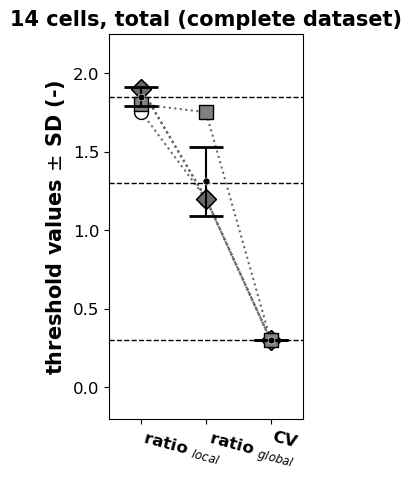

In [41]:
### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# style for markers    
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure
fig = plt.figure(1, (2.5,5))
ax = plt.subplot(1,1,1)
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
ax.set_xticks([1,2,3])

ax.set_xlim((0.5, 3.5))
# set y-axis limits to accomodate both the minimum and maximum values obtained in the analysis
ax.set_ylim((-0.2, 2.25))

ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)

# horizontal lines to visualise the obtained mean values for the 3 thresholds
ax.axhline(0.3, color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(1.3, color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(1.85, color = 'black', linestyle = 'dashed', linewidth = 1)
    
labels = ["ratio " + r'$_{local}$', "ratio "+r'$_{global}$', "CV"]
ax.set_xticklabels(labels, fontweight = 'bold', rotation = -15, ha = 'left')
ax.set_ylabel("threshold values " r'$\pm$ SD (-)', fontweight = 'bold', fontsize = size_labels)
        


local = []; combination = []; cv = []
for i1 in range(len(thresholds_outcomes)):
    outcome = thresholds_outcomes[i1]
    local.append(outcome[0]); combination.append(outcome[1]); cv.append(outcome[2])
    ax.scatter([1, 2, 3], outcome, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax.plot([1,2,3], outcome, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

    
thresholds_mean = [np.mean(local), np.mean(combination), np.mean(cv)]; thresholds_sd = [np.std(local), np.std(combination), np.std(cv)]
print(thresholds_mean)
ax.errorbar([1, 2, 3], thresholds_mean, fmt = 'none', yerr = thresholds_sd, ecolor = 'black', elinewidth = 1.5, capsize = 12.5, capthick = 2, zorder = 3)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'white', s = 75, zorder = 4)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'black', s = 50, zorder = 4)




**B). difference between # puncta found by algorithm and # puncta identified by eye**
_1)_ for training set (used to determine threshold values)

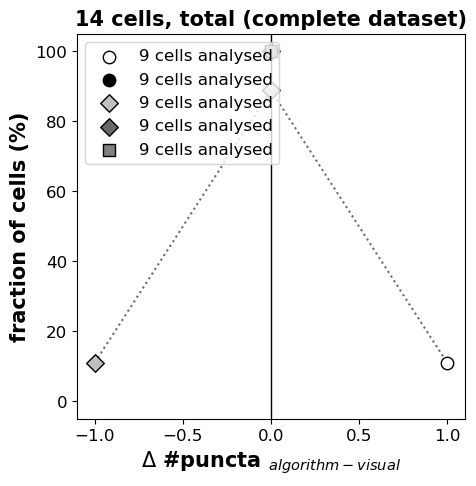

In [35]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_training_outcomes)):
    data_i2 = delta_training_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_training[i2]) + " cells analysed")
    
ax.legend(loc = 'upper left', fontsize = size_ticks)


_2)_ for test set (**NOT** used to determine threshold values)

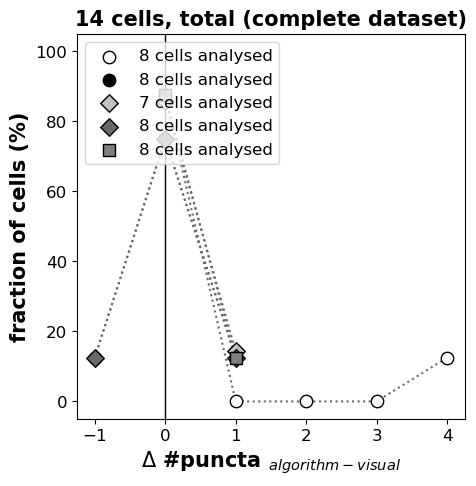

In [36]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_test_outcomes)):
    data_i2 = delta_test_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_test[i2]) + " cells analysed")
    
ax.legend(loc = 'upper left', fontsize = size_ticks)


**C). FP and FN occurrence rates**
_1)_ for training set (used to determine threshold values)

C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\3490558044.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


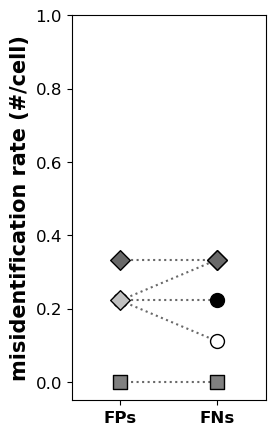

In [42]:
# FP and FN rates obtained from TRAINING DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    training = np.array(training_outcomes[i1]); training_corrected = (training/training[-1])[:-1] # divide by # cells to convert to rate
    combined = list(training_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    
    

_2)_ for test set (**NOT** used to determine threshold values)

C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\471364339.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


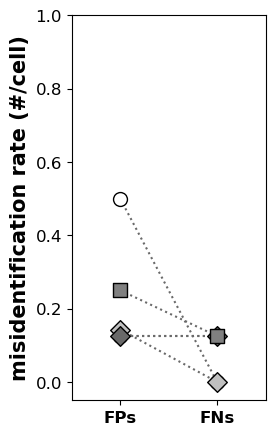

In [43]:
# FP and FN rates obtained from TEST DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    test = np.array(test_outcomes[i1]); test_corrected = (test/test[-1])[:-1] # divide by # cells to convert to rate
    combined = list(test_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    
    

## Thresholds for _clear (but somewhat dimmer)_ puncta

FNs = locations with state = `"punctum (clear)"` that do not satisfy all selection criteria

FPs = `"nonpunctate"` and `"miscellaneous"` locations that do satisfy all selection criteria

**NB.** `"punctum (brightest)"` are not assessed at all, perform separate analysis for this category (see above)

In [44]:
identifiers = list(set(list(validated_gfp["cellID"]))) # column i1 contains a unique identifier for each cell in the validated dataset
N_cells_validated = len(set(list(validated_gfp["cellID"]))) # total number of cells included in the dataset

# empty lists to store test outcomes
thresholds_outcomes = []; training_outcomes = []; test_outcomes = []
delta_training_outcomes = []; delta_test_outcomes = []
N_training = []; N_test = []
for i1 in range(iterations):    
    ### 1. create training data set (~66% of data) and test data set (~33% of data)
    identifiers_training = random.choices(identifiers, k = int(2/3*N_cells_validated)) # randomly sample ~66% of data set, WITH replacement (to create the training set)
    identifiers_test = [ID for ID in identifiers if ID not in identifiers_training] # all cells that are NOT in training set go to test set
    
    N_training.append(len(identifiers_training)); N_test.append(len(identifiers_test))
    # create separate dataframes for the training and test set    
    df_training = pd.DataFrame({})
    for i2 in identifiers_training:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_training = pd.concat([df_training, df_cell])
            
    df_test = pd.DataFrame({})
    for i2 in identifiers_test:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_test = pd.concat([df_test, df_cell])
        
    ### 2. run optimization to find optimal threshold value combination
    ### a. test all threshold value combinations
    test_statistic = []; thresholds_tested = []; FP = []; FN = []; FP_test = []; FN_test = []

    for a in ratio_local_test: # loop over different values for ratio punctum/surroundings
        for b in ratio_overall_test: # loop over different values for average intensity punctum/cell
            for c in cv_test: # loop over different values for normalized standard deviation (sd punctum/av punctum)
                # dataframes containing puncta that do/do not satisfy the current set of criteria
                satisfied = df_training[(df_training["intensity ratio, local"] >= a) & (df_training["intensity ratio, overall"] >= b) & (df_training["CV"] <= c)]
                not_satisfied = df_training[(df_training["intensity ratio, local"] < a) | (df_training["intensity ratio, overall"] < b) | (df_training["CV"] > c)]

                # identify false positives (from df with accepted puncta)
                df_FP = satisfied[satisfied["state"].isin(["nonpunctate", "miscellaneous"])]

                # identify false negatives (from df with rejected puncta)
                df_FN = not_satisfied[not_satisfied["state"] == "punctum (clear)"]

                # calculate and store test statistic; also store the implemented combination of threshold values 
                test_statistic.append(len(df_FP) + FN_weight*len(df_FN))
                thresholds_tested.append([a,b,c])

                # store the number of false positives and false negatives
                FP.append(len(df_FP)); FN.append(len(df_FN))
                    
                # b. Apply the same 3 thresholds to the test set and determine # of FPs and FNs
                test_satisfied = df_test[(df_test["intensity ratio, local"] >= a) & (df_test["intensity ratio, overall"] >= b) & (df_test["CV"] <= c)]
                test_not_satisfied = df_test[(df_test["intensity ratio, local"] < a) | (df_test["intensity ratio, overall"] < b) | (df_test["CV"] > c)]
                    
                test_df_FP = test_satisfied[test_satisfied["state"].isin(["miscellaneous", "nonpunctate"])]
                test_df_FN = test_not_satisfied[test_not_satisfied["state"] == "punctum (clear)"]
                    
                # store the number of false positives and false negatives
                FP_test.append(len(test_df_FP)); FN_test.append(len(test_df_FN))
        
    ### 3. identify combination that yields minimum of test statistic and save its performance parameters
    index_min = test_statistic.index(min(test_statistic)) # index at which position the minimum test statistic value occurs
    thresholds_combination = thresholds_tested[index_min] # most stringent combination of thresholds that gives optimal outcome
    thresholds_outcomes.append(thresholds_combination)
    training_outcomes.append([FP[index_min], FN[index_min], len(identifiers_training)]) # [# FPs, # FNs, # cells in training set]
    test_outcomes.append([FP_test[index_min], FN_test[index_min], len(identifiers_test)])
   
    ### progress visualiser:
    print("iteration", i1, "finished; obtained threshold values:", thresholds_combination)
        
    ### 4. for INDIVIDUAL cells calculate puncta algorithm - puncta validated; measure accuracy/applicability of obtained best thresholds
    ### a. training set
    delta_training = []
    for i2 in identifiers_training:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered = df_detected[df_detected["state"] != "punctum (brightest)"] # exclude any "punctum (clear)"
        df_visual = df_cell[df_cell["state"] == "punctum (clear)"]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_training.append(delta)
            
    delta_training_outcomes.append(delta_training)
            
    ### b. test set
    delta_test = []
    for i2 in identifiers_test:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered = df_detected[df_detected["state"] != "punctum (brightest)"] # exclude any "punctum (clear)"
        df_visual = df_cell[df_cell["state"] == "punctum (clear)"]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_test.append(delta)
            
    delta_test_outcomes.append(delta_test)

iteration 0 finished; obtained threshold values: [1.6500000000000004, 1.2, 0.45000000000000007]
iteration 1 finished; obtained threshold values: [1.8000000000000005, 1.7500000000000004, 0.30000000000000004]
iteration 2 finished; obtained threshold values: [1.6500000000000004, 1.9000000000000006, 0.30000000000000004]
iteration 3 finished; obtained threshold values: [1.9000000000000006, 1.2, 0.30000000000000004]
iteration 4 finished; obtained threshold values: [1.8000000000000005, 1.7500000000000004, 0.45000000000000007]


### Visualise outcomes of threshold determination

**A). Obtained threshold values**

[1.7600000000000005, 1.56, 0.36000000000000004]


C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\2724712972.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([1,2,3], outcome, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


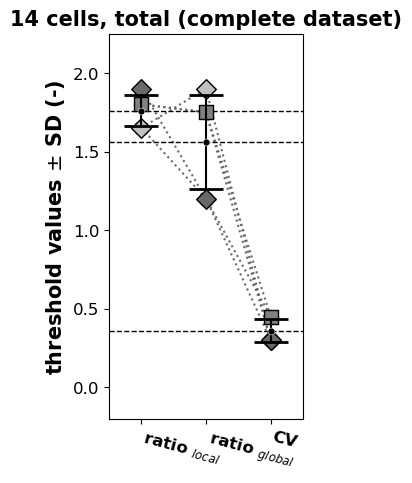

In [46]:
### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# style for markers    
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure
fig = plt.figure(1, (2.5,5))
ax = plt.subplot(1,1,1)
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
ax.set_xticks([1,2,3])

ax.set_xlim((0.5, 3.5))
# set y-axis limits to accomodate both the minimum and maximum values obtained in the analysis
ax.set_ylim((-0.2, 2.25))

ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)

# horizontal lines to visualise the obtained mean values for the 3 thresholds
ax.axhline(0.36, color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(1.56, color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(1.76, color = 'black', linestyle = 'dashed', linewidth = 1)
    
labels = ["ratio " + r'$_{local}$', "ratio "+r'$_{global}$', "CV"]
ax.set_xticklabels(labels, fontweight = 'bold', rotation = -15, ha = 'left')
ax.set_ylabel("threshold values " r'$\pm$ SD (-)', fontweight = 'bold', fontsize = size_labels)
        


local = []; combination = []; cv = []
for i1 in range(len(thresholds_outcomes)):
    outcome = thresholds_outcomes[i1]
    local.append(outcome[0]); combination.append(outcome[1]); cv.append(outcome[2])
    ax.scatter([1, 2, 3], outcome, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax.plot([1,2,3], outcome, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

    
thresholds_mean = [np.mean(local), np.mean(combination), np.mean(cv)]; thresholds_sd = [np.std(local), np.std(combination), np.std(cv)]
print(thresholds_mean)
ax.errorbar([1, 2, 3], thresholds_mean, fmt = 'none', yerr = thresholds_sd, ecolor = 'black', elinewidth = 1.5, capsize = 12.5, capthick = 2, zorder = 3)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'white', s = 75, zorder = 4)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'black', s = 50, zorder = 4)

**B). difference between # puncta found by algorithm and # puncta identified by eye**
_1)_ for training set (used to determine threshold values)

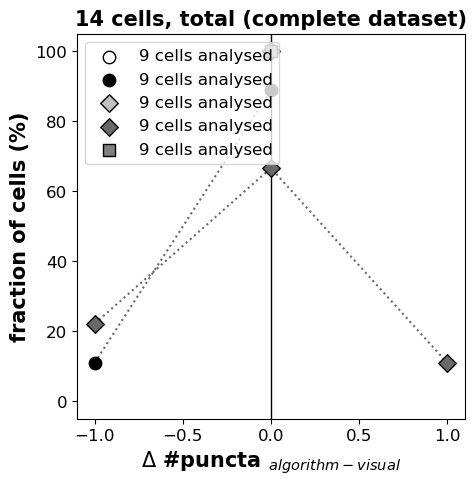

In [47]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_training_outcomes)):
    data_i2 = delta_training_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_training[i2]) + " cells analysed")
    
ax.legend(loc = 'upper left', fontsize = size_ticks)

_2)_ for test set (**NOT** used to determine threshold values)

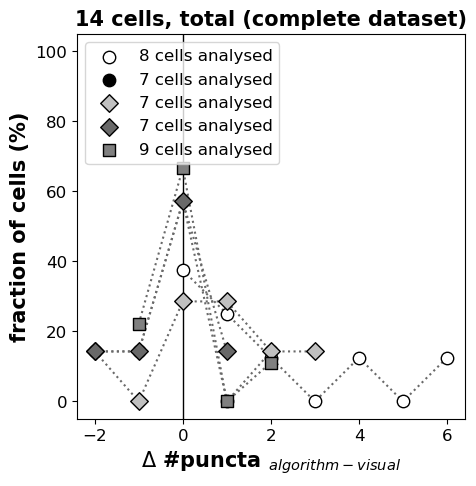

In [48]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_test_outcomes)):
    data_i2 = delta_test_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_test[i2]) + " cells analysed")
    
ax.legend(loc = 'upper left', fontsize = size_ticks)

**C). FP and FN occurrence rates**
_1)_ for training set (used to determine threshold values)

C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\3991542004.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


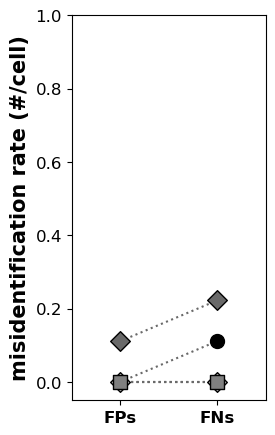

In [49]:
# FP and FN rates obtained from TRAINING DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    training = np.array(training_outcomes[i1]); training_corrected = (training/training[-1])[:-1] # divide by # cells to convert to rate
    combined = list(training_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

_2)_ for test set (**NOT** used to determine threshold values)

C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\1401472922.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


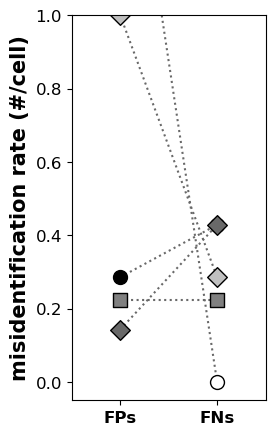

In [50]:
# FP and FN rates obtained from TEST DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    test = np.array(test_outcomes[i1]); test_corrected = (test/test[-1])[:-1] # divide by # cells to convert to rate
    combined = list(test_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

## Thresholds for _miscellaneous_ puncta

FNs = locations with state = `"miscellaneous"` puncta that do not satisfy all selection criteria

FPs = `"nonpunctate"` locations that do satisfy all selection criteria

**NB.** locations that are labeled as `punctum (brightest)"` or `"punctum (clear)"` are not assessed at all, perform separate analysis for these categories

In [51]:
identifiers = list(set(list(validated_gfp["cellID"]))) # column i1 contains a unique identifier for each cell in the validated dataset
N_cells_validated = len(set(list(validated_gfp["cellID"]))) # total number of cells included in the dataset

# empty lists to store test outcomes
thresholds_outcomes = []; training_outcomes = []; test_outcomes = []
delta_training_outcomes = []; delta_test_outcomes = []
N_training = []; N_test = []
for i1 in range(iterations):    
    ### 1. create training data set (~66% of data) and test data set (~33% of data)
    identifiers_training = random.choices(identifiers, k = int(2/3*N_cells_validated)) # randomly sample ~66% of data set, WITH replacement (to create the training set)
    identifiers_test = [ID for ID in identifiers if ID not in identifiers_training] # all cells that are NOT in training set go to test set
    
    N_training.append(len(identifiers_training)); N_test.append(len(identifiers_test))
    # create separate dataframes for the training and test set    
    df_training = pd.DataFrame({})
    for i2 in identifiers_training:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_training = pd.concat([df_training, df_cell])
            
    df_test = pd.DataFrame({})
    for i2 in identifiers_test:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_test = pd.concat([df_test, df_cell])
        
    ### 2. run optimization to find optimal threshold value combination
    ### a. test all threshold value combinations
    test_statistic = []; thresholds_tested = []; FP = []; FN = []; FP_test = []; FN_test = []

    for a in ratio_local_test: # loop over different values for ratio punctum/surroundings
        for b in ratio_overall_test: # loop over different values for average intensity punctum/cell
            for c in cv_test: # loop over different values for normalized standard deviation (sd punctum/av punctum)
                # dataframes containing puncta that do/do not satisfy the current set of criteria
                satisfied = df_training[(df_training["intensity ratio, local"] >= a) & (df_training["intensity ratio, overall"] >= b) & (df_training["CV"] <= c)]
                not_satisfied = df_training[(df_training["intensity ratio, local"] < a) | (df_training["intensity ratio, overall"] < b) | (df_training["CV"] > c)]

                # identify false positives (from df with accepted puncta)
                df_FP = satisfied[satisfied["state"].isin(["nonpunctate"])]

                # identify false negatives (from df with rejected puncta)
                df_FN = not_satisfied[not_satisfied["state"] == "miscellaneous"]

                # calculate and store test statistic; also store the implemented combination of threshold values 
                test_statistic.append(len(df_FP) + FN_weight*len(df_FN))
                thresholds_tested.append([a,b,c])

                # store the number of false positives and false negatives
                FP.append(len(df_FP)); FN.append(len(df_FN))
                    
                # b. Apply the same 3 thresholds to the test set and determine # of FPs and FNs
                test_satisfied = df_test[(df_test["intensity ratio, local"] >= a) & (df_test["intensity ratio, overall"] >= b) & (df_test["CV"] <= c)]
                test_not_satisfied = df_test[(df_test["intensity ratio, local"] < a) | (df_test["intensity ratio, overall"] < b) | (df_test["CV"] > c)]
                    
                test_df_FP = test_satisfied[test_satisfied["state"].isin(["nonpunctate"])]
                test_df_FN = test_not_satisfied[test_not_satisfied["state"] == "miscellaneous"]
                    
                # store the number of false positives and false negatives
                FP_test.append(len(test_df_FP)); FN_test.append(len(test_df_FN))
        
    ### 3. identify combination that yields minimum of test statistic and save its performance parameters
    index_min = test_statistic.index(min(test_statistic)) # index at which position the minimum test statistic value occurs
    thresholds_combination = thresholds_tested[index_min] # most stringent combination of thresholds that gives optimal outcome
    thresholds_outcomes.append(thresholds_combination)
    training_outcomes.append([FP[index_min], FN[index_min], len(identifiers_training)]) # [# FPs, # FNs, # cells in training set]
    test_outcomes.append([FP_test[index_min], FN_test[index_min], len(identifiers_test)])
   
    ### progress visualiser:
    print("iteration", i1, "finished; obtained threshold values:", thresholds_combination)
        
    ### 4. for INDIVIDUAL cells calculate puncta algorithm - puncta validated; measure accuracy/applicability of obtained best thresholds
    ### a. training set
    delta_training = []
    for i2 in identifiers_training:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered_ = df_detected[df_detected["state"] != "punctum (brightest)"] # exclude any "punctum (brightest)"
        df_detected_filtered = df_detected_filtered_[df_detected_filtered_["state"] != "punctum (clear)"] # exclude any "punctum (clear)"
        df_visual = df_cell[df_cell["state"] == "miscellaneous"]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_training.append(delta)
            
    delta_training_outcomes.append(delta_training)
            
    ### b. test set
    delta_test = []
    for i2 in identifiers_test:
        df_cell = validated_gfp[validated_gfp["cellID"] == i2]
        df_detected = df_cell[(df_cell["intensity ratio, local"] >= thresholds_combination[0]) & (df_cell["intensity ratio, overall"] >= thresholds_combination[1]) & (df_cell["CV"] <= thresholds_combination[2])]
        df_detected_filtered_ = df_detected[df_detected["state"] != "punctum (brightest)"] # exclude any "punctum (brightest)"
        df_detected_filtered = df_detected_filtered_[df_detected_filtered_["state"] != "punctum (clear)"] # exclude any "punctum (clear)"
        df_visual = df_cell[df_cell["state"] == "miscellaneous"]
        delta = len(df_detected_filtered) - len(df_visual)
        delta_test.append(delta)
            
    delta_test_outcomes.append(delta_test)

iteration 0 finished; obtained threshold values: [1.5000000000000002, 1.7500000000000004, 0.3500000000000001]
iteration 1 finished; obtained threshold values: [1.4500000000000002, 1.7500000000000004, 0.40000000000000013]
iteration 2 finished; obtained threshold values: [1.3, 1.8000000000000005, 0.3500000000000001]
iteration 3 finished; obtained threshold values: [1.3, 1.7000000000000004, 0.40000000000000013]
iteration 4 finished; obtained threshold values: [1.4500000000000002, 1.7500000000000004, 0.40000000000000013]


### Visualise outcomes of threshold determination

**A). Obtained threshold values**

[1.4, 1.7500000000000004, 0.3800000000000001]


C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\3522175112.py:39: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot([1,2,3], outcome, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


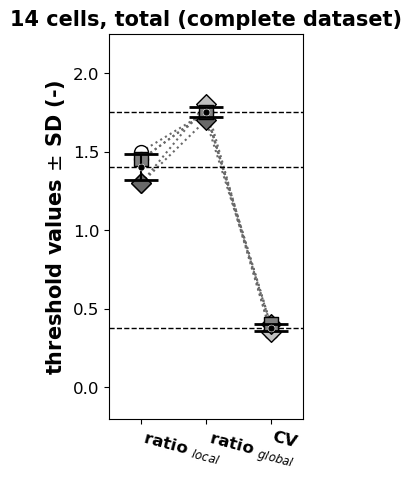

In [57]:
### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# style for markers    
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure
fig = plt.figure(1, (2.5,5))
ax = plt.subplot(1,1,1)
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
ax.set_xticks([1,2,3])

ax.set_xlim((0.5, 3.5))
# set y-axis limits to accomodate both the minimum and maximum values obtained in the analysis
ax.set_ylim((-0.2, 2.25))

ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)

# horizontal lines to visualise the obtained mean values for the 3 thresholds
ax.axhline(0.38, color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(1.4, color = 'black', linestyle = 'dashed', linewidth = 1)
ax.axhline(1.75, color = 'black', linestyle = 'dashed', linewidth = 1)
    
labels = ["ratio " + r'$_{local}$', "ratio "+r'$_{global}$', "CV"]
ax.set_xticklabels(labels, fontweight = 'bold', rotation = -15, ha = 'left')
ax.set_ylabel("threshold values " r'$\pm$ SD (-)', fontweight = 'bold', fontsize = size_labels)
        


local = []; combination = []; cv = []
for i1 in range(len(thresholds_outcomes)):
    outcome = thresholds_outcomes[i1]
    local.append(outcome[0]); combination.append(outcome[1]); cv.append(outcome[2])
    ax.scatter([1, 2, 3], outcome, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax.plot([1,2,3], outcome, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

    
thresholds_mean = [np.mean(local), np.mean(combination), np.mean(cv)]; thresholds_sd = [np.std(local), np.std(combination), np.std(cv)]
print(thresholds_mean)
ax.errorbar([1, 2, 3], thresholds_mean, fmt = 'none', yerr = thresholds_sd, ecolor = 'black', elinewidth = 1.5, capsize = 12.5, capthick = 2, zorder = 3)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'white', s = 75, zorder = 4)
ax.scatter([1, 2, 3], thresholds_mean, marker = '.', color = 'black', s = 50, zorder = 4)

**B). difference between # puncta found by algorithm and # puncta identified by eye**
_1)_ for training set (used to determine threshold values)

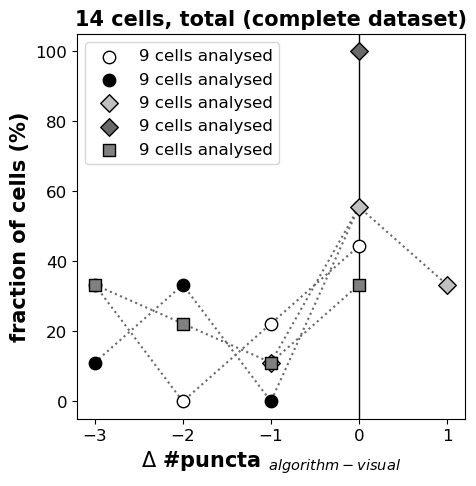

In [58]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_training_outcomes)):
    data_i2 = delta_training_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_training[i2]) + " cells analysed")
    
ax.legend(loc = 'upper left', fontsize = size_ticks)

_2)_ for test set (**NOT** used to determine threshold values)

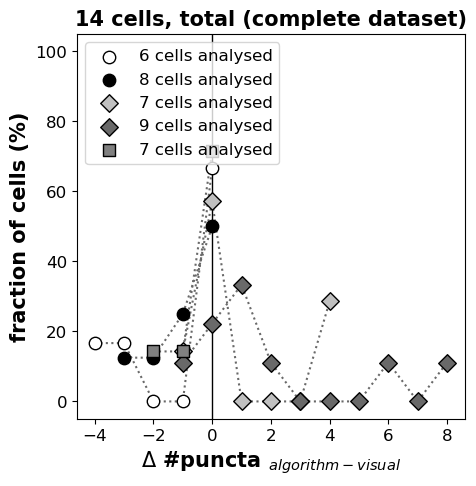

In [54]:
# markers/lines for different iterations
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# text sizes
size_labels = 15
size_ticks = 12

# initiate the figure
fig = plt.figure(1, (5,5))
    
ax = plt.subplot(1,1,1)
ax.tick_params(axis = 'y', labelsize = size_ticks)
ax.tick_params(axis = 'x', labelsize = size_ticks)
ax.set_ylim((-5,105))
    
ax.set_title(str(N_cells_validated) + " cells, total (complete dataset)", fontweight = 'bold', fontsize = size_labels)
    
ax.set_ylabel("fraction of cells (%)", fontweight = 'bold', fontsize = size_labels)
ax.set_xlabel(r'$\Delta$ #puncta $_{algorithm-visual}$', fontweight = 'bold', fontsize = size_labels)


# vertical line at delta = 0 (visual and algorithm give identical result)
ax.axvline(0, color = 'black', linewidth = 1, zorder = 0)

# get data to plot
for i2 in range(len(delta_test_outcomes)):
    data_i2 = delta_test_outcomes[i2]
    # determine the values to plot
    x = []; y = []
    for i3 in np.arange(min(data_i2), max(data_i2)+1): # loop over individual values
        x.append(i3)
        freq = data_i2.count(i3)/len(data_i2)
        y.append(freq*100)
        
    ax.plot(x, y, color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)
    ax.scatter(x, y, marker = markers[i2], s = 80, facecolors = face[i2], edgecolors = edge[i2], zorder = 2, label = str(N_test[i2]) + " cells analysed")
    
ax.legend(loc = 'upper left', fontsize = size_ticks)

**C). FP and FN occurrence rates**
_1)_ for training set (used to determine threshold values)

C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\3991542004.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


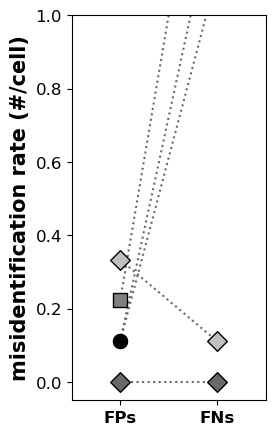

In [55]:
# FP and FN rates obtained from TRAINING DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    training = np.array(training_outcomes[i1]); training_corrected = (training/training[-1])[:-1] # divide by # cells to convert to rate
    combined = list(training_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)

_2)_ for test set (**NOT** used to determine threshold values)

C:\Users\hanna\AppData\Local\Temp\ipykernel_13968\1401472922.py:32: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)


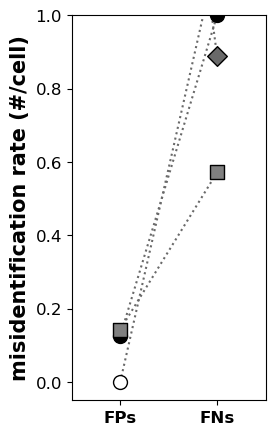

In [56]:
# FP and FN rates obtained from TEST DATA

### optimal threshold value combinations identified
size_labels = 15
size_ticks = 12

# for marker look
face = ["white", "black", "silver", "dimgrey", "grey"]
edge = ['black', 'black', 'black', 'black', 'black']
markers = ["o", "o", "D", "D", "s"]

# initiate figure and subplot
fig = plt.figure(1, (2.5,5))
ax1 = plt.subplot(1,1,1)

ax1.tick_params(axis = 'y', labelsize = size_ticks)
ax1.tick_params(axis = 'x', labelsize = size_ticks)

ax1.set_xlim((0.5, 2.5))
ax1.set_ylim((-0.05, 1))

ax1.set_xticks([1,2])
labels = ["FPs", "FNs"]
ax1.set_xticklabels(labels, fontweight = 'bold', rotation = -0, ha = 'center')
ax1.set_ylabel("misidentification rate (#/cell)", fontweight = 'bold', fontsize = size_labels)


for i1 in range(len(training_outcomes)):
    test = np.array(test_outcomes[i1]); test_corrected = (test/test[-1])[:-1] # divide by # cells to convert to rate
    combined = list(test_corrected)
    ax1.scatter([1, 2], combined, marker = markers[i1], facecolors = face[i1], edgecolors = edge[i1], s = 100, alpha = 1, zorder = 2)
    ax1.plot([1, 2], combined, '-', color = 'dimgrey', linewidth = 1.5, linestyle = 'dotted', zorder = 1)